In [62]:
import numpy as np
import pickle
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

In [63]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import svm, datasets
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import auc
from sklearn.metrics import RocCurveDisplay
from sklearn.model_selection import StratifiedKFold
import numpy as np
from sklearn.metrics import roc_auc_score
from sklearn.metrics import PrecisionRecallDisplay

In [64]:
journal_info = pd.read_csv('..\\data\\doaj_journal_list_urls_from_doaj_bing_v1.csv')

In [65]:
journal_info.shape

(15395, 11)

In [66]:
journal_info['ISSN'] = journal_info['ISSN'].apply(str.strip)

In [67]:
journal_info

,Unnamed: 0,Journal_Title_Normalized,added,Journal Title,ISSN,Remove_Date,Add_Date,Reason,Data Source,URL,reason_category
0,0,"#tear: revista de educação, ciência e tecnologia",True,"#Tear: Revista de Educação, Ciência e Tecnologia",2238-8079,1677-09-22,2015-07-20,Still in DOAJ index,DOAJ,https://periodicos.ifrs.edu.br/index.php/tear/...,interesting reason
1,1,(en)clave comahue,True,(En)clave Comahue,2545-6466,1677-09-22,2019-05-13,Still in DOAJ index,DOAJ,http://revele.uncoma.edu.ar/htdoc/revele/index...,interesting reason
2,2,(پژوهش حسابداری و حسابرسی (پیوسته,True,(پژوهش حسابداری و حسابرسی (پیوسته,2676-7554,1677-09-22,2020-05-25,Still in DOAJ index,DOAJ,https://ijar.alzahra.ac.ir/,interesting reason
3,3,100-cs,True,100-Cs,0719-5737,1677-09-22,2018-12-27,Still in DOAJ index,DOAJ,http://100cs.cl/,interesting reason
4,4,1616,True,1616,0210-7287,1677-09-22,2020-03-09,Still in DOAJ index,DOAJ,http://revistas.usal.es/index.php/1616_Anuario...,interesting reason
...,...,...,...,...,...,...,...,...,...,...,...
15390,15405,силовое и энергетическое оборудование: автоном...,False,Силовое и энергетическое оборудование: Автоном...,2618-8716,2020-11-19,1677-09-22,Website URLs have security issues,DOAJ,https://onlinebooks.library.upenn.edu/webbin/b...,interesting reason
15391,15406,українська біографістика,False,Українська біографістика,2520-2855,2021-02-11,1677-09-22,Journal not adhering to best practice,DOAJ,http://ub.nbuv.gov.ua/,interesting reason
15392,15407,экономика региона,False,Экономика региона,2072-6414,2021-03-01,1677-09-22,Journal not adhering to Best practice,DOAJ,https://economyofregion.ru/,interesting reason
15393,15408,اندیشه‌های نوین تربیتی,False,اندیشه‌های نوین تربیتی,2476-7654,2022-06-09,1677-09-22,Journal not adhering to Best practice,DOAJ,http://ensani.ir/fa/article/journal/65/%D8%A7%...,interesting reason


# After scraped journal websites and extracted website-based features, you can run the code below

In [70]:
web_features1 = []
web_features0 = []
tmp = []

journal_issns0 = []
journal_issns1 = []

for batch in range(0,100):
    with open('labeled_journal_feature_2025\\web_content_features_1_'+str(batch)+'.pkl', 'rb') as f:
        web_features1 += pickle.load(f)
        
journal_issns1 += journal_info[journal_info['Reason']!='Still in DOAJ index']['ISSN'].tolist()
print(len(web_features1),len(journal_issns1))    
    
for batch in range(0,100):
    with open('labeled_journal_feature_2025\\web_content_features_0_'+str(batch)+'.pkl', 'rb') as f:
        web_features0 += pickle.load(f)
        
journal_issns0 += journal_info[journal_info['Reason']=='Still in DOAJ index']['ISSN'].tolist()
print(len(web_features0),len(journal_issns0))   

#print('content feature')
#print(web_features1)
#print(web_features0)
#print(len(web_features1))
#print(len(web_features0))


web_not_working = [ind for ind,ft in enumerate(web_features1) if ft[0] =='Empty']
web_not_english = [ind for ind,ft in enumerate(web_features1) if ft[0] =='Non-EN']
web_not = [ind for ind,ft in enumerate(web_features1) if len(ft) <=9]
#print(web_features1[1])
web_features_1 = [ft for ft in web_features1 if len(ft) >9]

journal_issns_1 = [journal_issns1[ind] for ind,ft in enumerate(web_features1) if len(ft) >9]

web_features_1b = [ft for ft in web_features1 if len(ft) >9]

print(len(web_features_1),len(journal_issns_1))  

unwhite_tb = pd.DataFrame(web_features_1)
unwhite_tb['label'] = 1

#print(web_features0)
web_not_working2 = [ind for ind,ft in enumerate(web_features0) if ft[0] =='Empty']
web_not_english2 = [ind for ind,ft in enumerate(web_features0) if ft[0] =='Non-EN']

web_features_0 = [ft for ft in web_features0 if len(ft) >9]

journal_issns_0 = [journal_issns0[ind] for ind,ft in enumerate(web_features0) if len(ft) >9]


web_features_0b = [ft for ft in web_features0 if len(ft) >9 ]

print(len(web_features_0),len(journal_issns_0)) 

white_tb = pd.DataFrame(web_features_0)
white_tb['label'] = 0

#print(len(web_features1))
#print(len(web_features0))

all_tb = pd.concat([unwhite_tb,white_tb]).reset_index(drop=True)

X1 = all_tb.loc[:, all_tb.columns != 'label']
y1 = all_tb.loc[:, all_tb.columns == 'label']

2536 2536
12859 12859
1980 1980
8729 8729


In [71]:
len(X1)

10709

In [73]:
X1.shape,len(web_features1+web_features0),len(web_features_1b+web_features_0b)

((10709, 17), 15395, 10709)

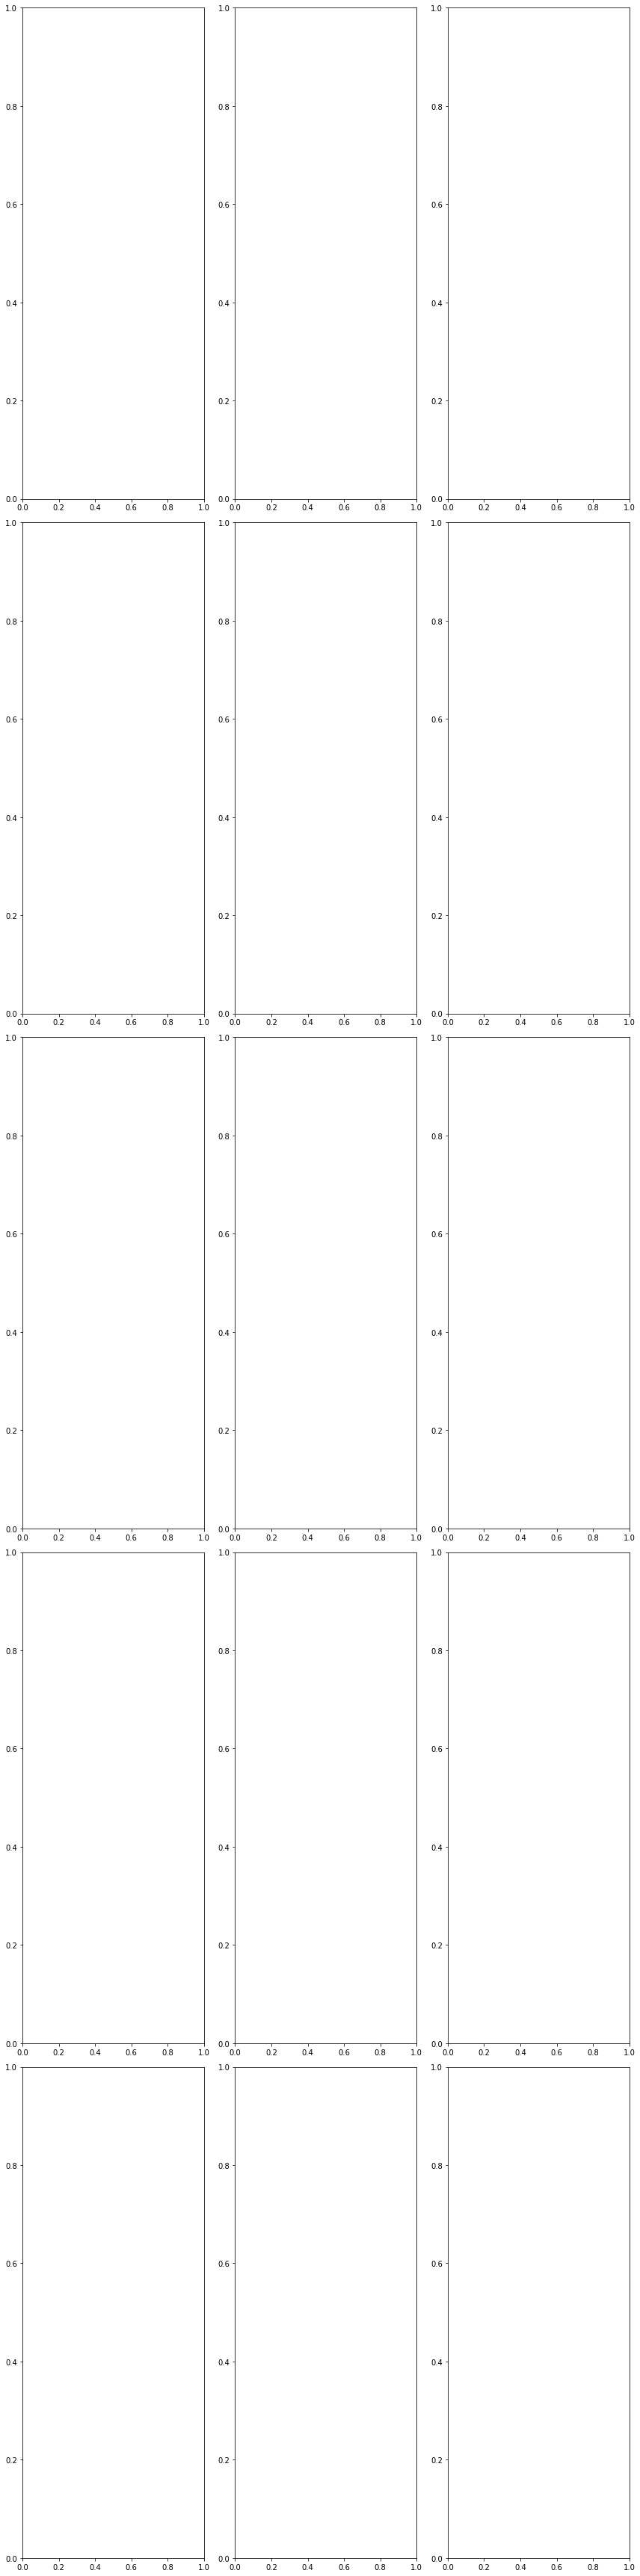

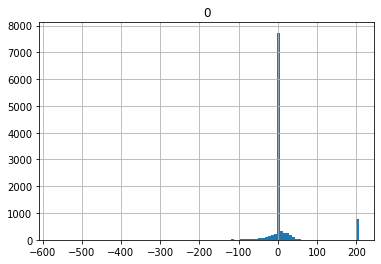

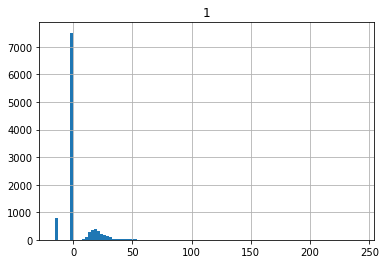

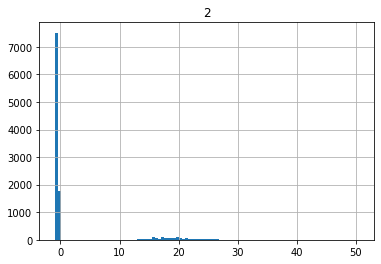

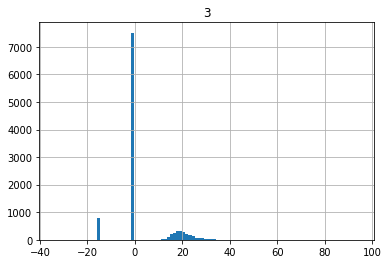

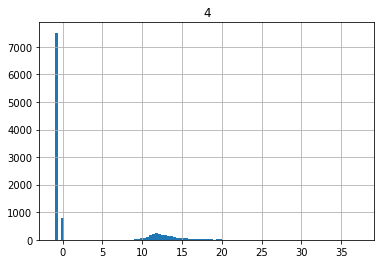

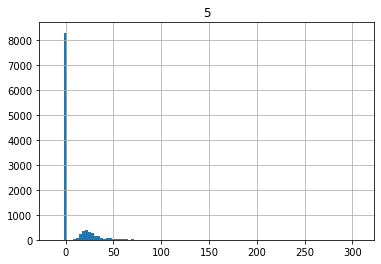

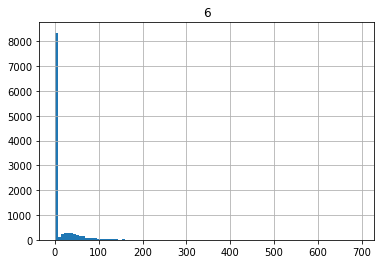

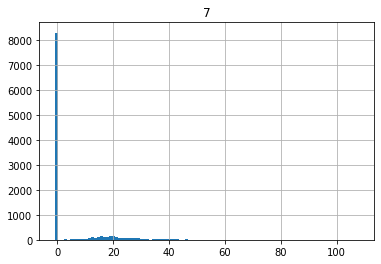

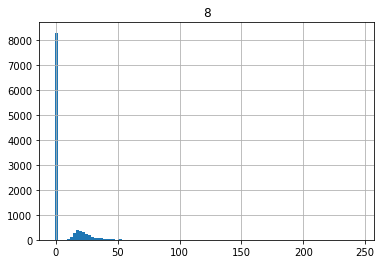

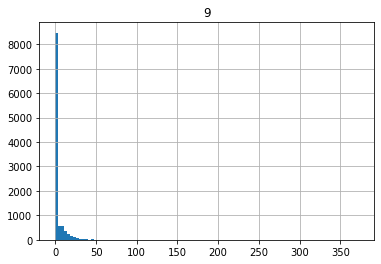

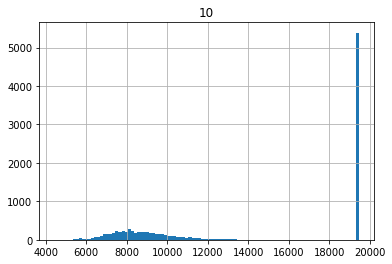

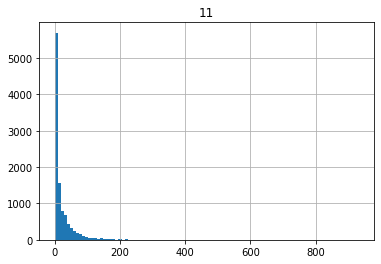

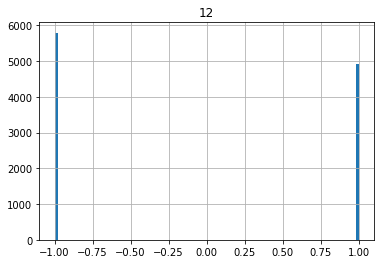

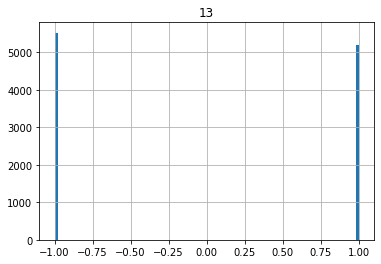

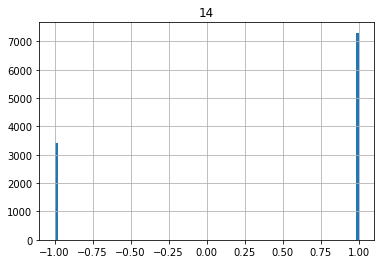

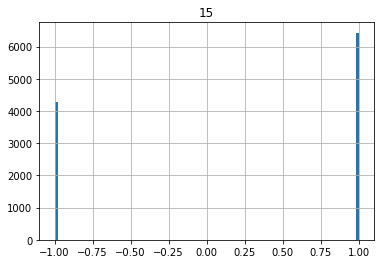

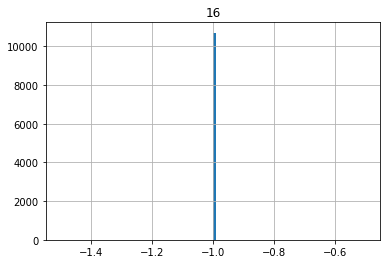

In [75]:
fig, axes = plt.subplots(len(X1.columns) // 3, 3, figsize=(12, 48))
for x in X1.columns:
    X1.hist(column = x, bins = 100)

fig.tight_layout()

In [76]:
np.mean(y1)

label    0.184891
dtype: float64

In [77]:
clf = RandomForestClassifier(max_depth=20,n_estimators = 500, random_state=0)

In [78]:
clf.fit(X1,y1)

<ipython-input-78-02e4c239c946>:1: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  clf.fit(X1,y1)


RandomForestClassifier(max_depth=20, n_estimators=500, random_state=0)

In [79]:
clf.score(X1,y1)

0.8844896815762443

In [80]:
clf.feature_importances_

array([0.02846053, 0.02424533, 0.01734136, 0.02943116, 0.02700558,
       0.02616458, 0.02587357, 0.02362375, 0.0268175 , 0.02933556,
       0.32028542, 0.26591667, 0.03389568, 0.04463586, 0.03608718,
       0.04088028, 0.        ])

In [81]:
np.mean(y1)

label    0.184891
dtype: float64

In [82]:
from sklearn.metrics import r2_score

In [83]:
r2_score(y1,clf.predict(X1))

0.2335409889940766

In [84]:
from sklearn import preprocessing

In [85]:
scaler = preprocessing.StandardScaler().fit(X1)

In [86]:
from sklearn.model_selection import train_test_split

In [87]:
X_train, X_test, y_train, y_test = train_test_split(
    X1, y1, test_size=0.3, random_state=7
)

In [88]:
lr = LogisticRegression(random_state=0,max_iter=1000).fit(scaler.transform(X_train), y_train)

C:\Users\hanzh\anaconda3\lib\site-packages\sklearn\utils\validation.py:1111: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [89]:
lr.coef_

array([[-0.14675789, -0.41390481, -0.10356471,  0.03147425,  0.0210291 ,
         0.10248316, -0.1946404 ,  0.09670483,  0.10793413,  0.14249057,
         0.26339014,  0.03376089, -0.00241802, -0.29938368, -0.13205465,
        -0.11620217,  0.        ]])

In [90]:
r2_score(y1,lr.predict(X1))

-4.408585858585857

In [91]:
clf.fit(X_train, y_train)

<ipython-input-91-4f66baab8f93>:1: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  clf.fit(X_train, y_train)


RandomForestClassifier(max_depth=20, n_estimators=500, random_state=0)

In [92]:
scaler = preprocessing.StandardScaler().fit(X1)

In [93]:
X1_fit = scaler.transform(X1)

In [94]:
X1_df = pd.DataFrame(X1_fit, columns = ["Flesch Reading Ease Score",
              "Flesch Kincaid Grade Level",
              "SMOG Index",
              "Coleman Liau Index",
              "Dale Chall Readability Score",
              "Automated Readability Index",
              "Difficult Words",
              "Linsear Write Formula",
              "Gunning FOG Formula",
              "Reading Time",
              "The Rank of Editorial Board Affiliations",
              "The Number of Editorial Board Members",
              "The Existence of Authorship Policy",
              "The Existence of Conflict of Interest Policy",
              "The Existence of Copyright Policy",
              "The Existence of Peer Review Policy",
              "not use"
             ])

In [95]:
del X1_df['not use']

In [96]:
data_regression = X1_df.copy()

In [97]:
data_regression.columns = [col.replace(' ','_')for col in X1_df.columns]

In [98]:
data_regression

,Flesch_Reading_Ease_Score,Flesch_Kincaid_Grade_Level,SMOG_Index,Coleman_Liau_Index,Dale_Chall_Readability_Score,Automated_Readability_Index,Difficult_Words,Linsear_Write_Formula,Gunning_FOG_Formula,Reading_Time,The_Rank_of_Editorial_Board_Affiliations,The_Number_of_Editorial_Board_Members,The_Existence_of_Authorship_Policy,The_Existence_of_Conflict_of_Interest_Policy,The_Existence_of_Copyright_Policy,The_Existence_of_Peer_Review_Policy
0,-0.542132,1.500424,-0.271276,1.893998,1.997045,1.412634,0.830622,1.580395,1.441464,0.418790,0.975007,-0.504053,-0.921720,1.032366,0.682335,0.815290
1,-0.239399,-0.338106,-0.408968,-0.354335,-0.544709,-0.448895,-0.392768,-0.444728,-0.468288,-0.338719,0.975007,-0.504053,-0.921720,-0.968649,-1.465556,-1.226558
2,-0.239399,-0.338106,-0.408968,-0.354335,-0.544709,-0.448895,-0.392768,-0.444728,-0.468288,-0.338719,-0.902605,0.304968,-0.921720,-0.968649,0.682335,-1.226558
3,0.282307,0.573624,-0.271276,2.161440,2.605328,0.918366,-0.154886,0.018157,0.676435,-0.153124,0.975007,-0.504053,1.084928,1.032366,0.682335,0.815290
4,-5.077317,4.348639,2.854330,7.083294,2.299515,5.540092,1.544266,1.368239,1.366493,3.832118,0.975007,-0.434708,1.084928,1.032366,0.682335,0.815290
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10704,-0.239399,-0.338106,-0.408968,-0.354335,-0.544709,-0.448895,-0.392768,-0.444728,-0.468288,-0.338719,0.975007,-0.504053,-0.921720,-0.968649,-1.465556,-1.226558
10705,-0.239399,-0.338106,-0.408968,-0.354335,-0.544709,-0.448895,-0.392768,-0.444728,-0.468288,-0.338719,0.975007,-0.504053,-0.921720,-0.968649,-1.465556,-1.226558
10706,-0.239399,-0.338106,-0.408968,-0.354335,-0.544709,-0.448895,-0.392768,-0.444728,-0.468288,-0.338719,-0.886335,0.050704,-0.921720,-0.968649,0.682335,-1.226558
10707,-0.239399,-0.338106,-0.408968,-0.354335,-0.544709,-0.448895,-0.392768,-0.444728,-0.468288,-0.338719,0.975007,-0.504053,1.084928,1.032366,0.682335,0.815290


In [99]:
data_regression['questionable_journal'] = y1

In [100]:
import statsmodels.formula.api as smf
from stargazer.stargazer import Stargazer

In [101]:
my_formula = "questionable_journal ~ " + " + ".join([col.replace(' ','_')for col in X1_df.columns])

In [102]:
my_formula

'questionable_journal ~ Flesch_Reading_Ease_Score + Flesch_Kincaid_Grade_Level + SMOG_Index + Coleman_Liau_Index + Dale_Chall_Readability_Score + Automated_Readability_Index + Difficult_Words + Linsear_Write_Formula + Gunning_FOG_Formula + Reading_Time + The_Rank_of_Editorial_Board_Affiliations + The_Number_of_Editorial_Board_Members + The_Existence_of_Authorship_Policy + The_Existence_of_Conflict_of_Interest_Policy + The_Existence_of_Copyright_Policy + The_Existence_of_Peer_Review_Policy'

In [103]:
log_reg = smf.logit(my_formula, data=data_regression).fit()

Optimization terminated successfully.
         Current function value: 0.451070
         Iterations 6


In [104]:
print(log_reg.summary())

                            Logit Regression Results                            
Dep. Variable:     questionable_journal   No. Observations:                10709
Model:                            Logit   Df Residuals:                    10692
Method:                             MLE   Df Model:                           16
Date:                  Thu, 17 Apr 2025   Pseudo R-squ.:                 0.05778
Time:                          15:07:31   Log-Likelihood:                -4830.5
converged:                         True   LL-Null:                       -5126.7
Covariance Type:              nonrobust   LLR p-value:                9.318e-116
                                                   coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------
Intercept                                       -1.6081      0.028    -57.959      0.000      -1.662      -1.554
Flesch_Readin

In [105]:
stargazer_tab = Stargazer([log_reg])

In [106]:
stargazer_tab

In [107]:
open('webcontent_regression.html', 'w').write(stargazer_tab.render_html())

3659

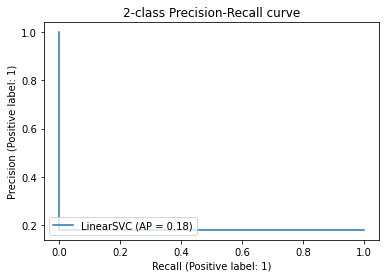

In [108]:
from sklearn.metrics import PrecisionRecallDisplay

display = PrecisionRecallDisplay.from_estimator(
    lr, X_test, y_test, name="LinearSVC"
)
_ = display.ax_.set_title("2-class Precision-Recall curve")

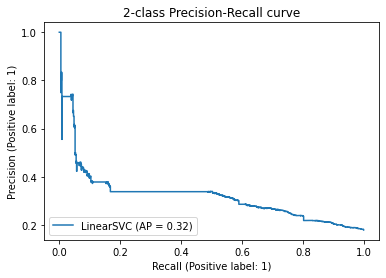

In [109]:
display = PrecisionRecallDisplay.from_estimator(
    clf, X_test, y_test, name="LinearSVC"
)
_ = display.ax_.set_title("2-class Precision-Recall curve")

<ipython-input-110-79310ebc04eb>:12: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  classifier.fit(X1.iloc[train], y1.iloc[train])
<ipython-input-110-79310ebc04eb>:12: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  classifier.fit(X1.iloc[train], y1.iloc[train])
<ipython-input-110-79310ebc04eb>:12: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  classifier.fit(X1.iloc[train], y1.iloc[train])
<ipython-input-110-79310ebc04eb>:12: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  classifier.fit(X1.iloc[train], y1.iloc[train])
<ipython-input-110-79310ebc04eb>:12:

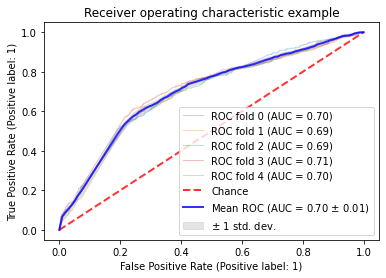

In [110]:
cv = StratifiedKFold(n_splits=5,random_state = 61,shuffle=True)
#classifier = svm.SVC( random_state=5)
#classifier = LogisticRegression(random_state=5)
#classifier = LogisticRegressionCV(random_state=5)
classifier = RandomForestClassifier(max_depth=20,n_estimators = 500, random_state=0)
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

fig, ax = plt.subplots()
for i, (train, test) in enumerate(cv.split(X1, y1)):
    classifier.fit(X1.iloc[train], y1.iloc[train])
    viz = RocCurveDisplay.from_estimator(
        classifier,
        X1.iloc[test],
        y1.iloc[test],
        name="ROC fold {}".format(i),
        alpha=0.3,
        lw=1,
        ax=ax,
    )
    interp_tpr = np.interp(mean_fpr, viz.fpr, viz.tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    aucs.append(viz.roc_auc)

ax.plot([0, 1], [0, 1], linestyle="--", lw=2, color="r", label="Chance", alpha=0.8)

mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)
ax.plot(
    mean_fpr,
    mean_tpr,
    color="b",
    label=r"Mean ROC (AUC = %0.2f $\pm$ %0.2f)" % (mean_auc, std_auc),
    lw=2,
    alpha=0.8,
)

std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
ax.fill_between(
    mean_fpr,
    tprs_lower,
    tprs_upper,
    color="grey",
    alpha=0.2,
    label=r"$\pm$ 1 std. dev.",
)

ax.set(
    xlim=[-0.05, 1.05],
    ylim=[-0.05, 1.05],
    title="Receiver operating characteristic example",
)
ax.legend(loc="lower right")
plt.show()

<ipython-input-111-65b716861c46>:12: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  classifier.fit(X1.iloc[train], y1.iloc[train])
<ipython-input-111-65b716861c46>:12: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  classifier.fit(X1.iloc[train], y1.iloc[train])
<ipython-input-111-65b716861c46>:12: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  classifier.fit(X1.iloc[train], y1.iloc[train])
<ipython-input-111-65b716861c46>:12: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  classifier.fit(X1.iloc[train], y1.iloc[train])
<ipython-input-111-65b716861c46>:12:

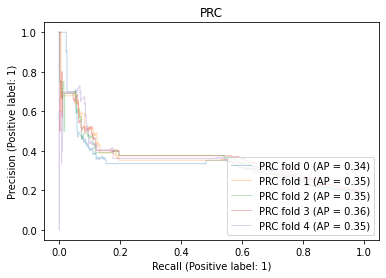

In [111]:
cv = StratifiedKFold(n_splits=5,random_state = 231,shuffle=True)
#classifier = svm.SVC( random_state=5)
#classifier = LogisticRegression(random_state=5)
#classifier = LogisticRegressionCV(random_state=5)
classifier = RandomForestClassifier(max_depth=20,n_estimators = 500, random_state=0,n_jobs=6)
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

fig, ax = plt.subplots()
for i, (train, test) in enumerate(cv.split(X1, y1)):
    classifier.fit(X1.iloc[train], y1.iloc[train])
    viz = PrecisionRecallDisplay.from_estimator(
        classifier,
        X1.iloc[test],
        y1.iloc[test],
        name="PRC fold {}".format(i),
        alpha=0.3,
        lw=1,
        ax=ax,
    )
    #interp_tpr = np.interp(mean_fpr, viz.fpr, viz.tpr)
    #interp_tpr[0] = 0.0
    #tprs.append(interp_tpr)
    #aucs.append(viz.roc_auc)



ax.set(
    xlim=[-0.05, 1.05],
    ylim=[-0.05, 1.05],
    title="PRC",
)
ax.legend(loc="lower right")
plt.show()

In [50]:
np.mean([0.34,0.35,0.35,0.36,0.35]),np.std([0.32,0.35,0.34,0.37,0.36])

(0.348, 0.017204650534085247)

In [112]:
np.mean([0.34,0.35,0.35,0.36,0.35]),np.std([0.34,0.35,0.35,0.36,0.35])

(0.35, 0.006324555320336747)

In [25]:
import numpy as np

# use bibliometrics to train AI model to predict questionable journals

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn import svm, datasets
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import auc
from sklearn.metrics import RocCurveDisplay
from sklearn.model_selection import StratifiedKFold
import numpy as np
from sklearn.metrics import roc_auc_score
from sklearn.metrics import PrecisionRecallDisplay

In [3]:
#drop two duplicated columns: save value but different column name
bibilometrics_raw = pd.read_csv('..\\data\\doaj_journals_biblio_features_v1.csv').drop(columns=['journal_paper_cited_num','journal_journal_reference_num'])

In [4]:
bibilometrics_raw.shape

(4430, 26)

In [5]:
journal_info = pd.read_csv('..\\data\\doaj_journal_list_urls_from_doaj_bing_v1.csv')

In [6]:
journal_info.shape

(15395, 11)

In [7]:
journal_info.columns

Index(['Unnamed: 0', 'Journal_Title_Normalized', 'added', 'Journal Title',
       'ISSN', 'Remove_Date', 'Add_Date', 'Reason', 'Data Source', 'URL',
       'reason_category'],
      dtype='object')

In [8]:
bibilometrics_raw[bibilometrics_raw['NormalizedName'].isin(journal_info['Journal_Title_Normalized'])].shape

(4417, 26)

In [9]:
bibilometrics = bibilometrics_raw[bibilometrics_raw['Issn'].isin(journal_info['ISSN'])]

In [10]:
bibilometrics.shape

(4417, 26)

In [11]:
bibilometrics.head(3)

,JournalId,NormalizedName,Reason,Issn,num_journal_publication,num_journal_author,num_journal_affiliation,journal_year_first_publish,journal_avg_hindex,journal_avg_first_author_hindex,...,journal_num_author_referenced,journal_num_author_cited,journal_num_affiliation_referenced,journal_num_affiliation_cited,journal_num_journal_self_reference,journal_num_author_self_reference,journal_num_affiliation_self_reference,journal_num_journal_self_cited,journal_num_author_self_cited,journal_num_affiliation_self_cited
0,2736556212,3c tic,Still in DOAJ index,2254-6529,200,59,59,2012,2.481504,2.423077,...,245,249,40,53,0,3,0,0,4,0
1,2764745361,aace clinical case reports,Still in DOAJ index,2376-0605,653,2458,2458,2014,10.629954,4.981982,...,38989,2810,1926,559,46,88,106,41,24,20
2,3035250834,aaps open,Still in DOAJ index,2364-9534,34,158,158,2015,9.055016,6.000000,...,3021,867,491,254,3,15,12,3,6,7


In [12]:
bibilometrics.shape

(4417, 26)

In [13]:
bibilometrics = bibilometrics.reindex(columns=['JournalId','NormalizedName','Issn','Reason','journal_year_first_publish',
                               'total_num_journal_cited','num_journal_publication','total_num_journal_reference','journal_num_journal_self_cited',
                              'journal_journal_cited_num','journal_paper_reference_num','journal_num_journal_self_reference',
                              'journal_avg_last_author_hindex','journal_num_author_self_cited',
                              'num_journal_author','journal_num_author_self_reference','journal_num_author_referenced',
                               'journal_avg_middle_author_hindex','journal_avg_first_author_hindex','journal_avg_hindex',
                               'journal_num_author_cited','journal_num_affiliation_cited','journal_num_affiliation_self_cited',
                               'num_journal_affiliation','journal_num_affiliation_referenced','journal_num_affiliation_self_reference'
                              ])

In [14]:
to_average = ['num_journal_author','num_journal_affiliation','total_num_journal_reference',
              'total_num_journal_cited','journal_journal_cited_num',
              'journal_num_author_referenced','journal_num_affiliation_referenced','journal_num_author_cited',
              'journal_num_affiliation_cited','journal_num_journal_self_reference','journal_num_author_self_reference',
              'journal_num_affiliation_self_reference','journal_num_journal_self_cited','journal_journal_cited_num'
             ]

In [15]:
to_ignore = ['journal_paper_cited','journal_journal_reference','journal_num_affiliation_self_reference','journal_num_author_self_cited','journal_num_affiliation_self_cited']

In [16]:
all_features = ['Reason','NormalizedName','journal_year_first_publish',
                               'total_num_journal_cited','num_journal_publication','total_num_journal_reference','journal_num_journal_self_cited',
                              'journal_journal_cited_num','journal_num_journal_self_reference',
                              'journal_avg_last_author_hindex','journal_num_author_self_cited',
                              'num_journal_author','journal_num_author_self_reference','journal_num_author_referenced',
                               'journal_avg_middle_author_hindex','journal_avg_first_author_hindex','journal_avg_hindex',
                               'journal_num_author_cited','journal_num_affiliation_cited','journal_num_affiliation_self_cited',
                               'num_journal_affiliation','journal_num_affiliation_referenced','journal_num_affiliation_self_reference'
                              ]
features_to_use = [f for f in all_features if f not in to_ignore] 

In [17]:
[f for f in to_average if f not in all_features ]

[]

In [18]:
bibilometrics1 = bibilometrics[bibilometrics['journal_paper_reference_num'] != 0]

In [19]:
bibilometrics2 = bibilometrics1[bibilometrics1['num_journal_author'] != 0]

In [20]:
bibilometrics3 = bibilometrics2[bibilometrics2['num_journal_publication']>10]

In [21]:
bibilometrics3[bibilometrics3['journal_num_affiliation_referenced'] == 0]

,JournalId,NormalizedName,Issn,Reason,journal_year_first_publish,total_num_journal_cited,num_journal_publication,total_num_journal_reference,journal_num_journal_self_cited,journal_journal_cited_num,...,journal_num_author_referenced,journal_avg_middle_author_hindex,journal_avg_first_author_hindex,journal_avg_hindex,journal_num_author_cited,journal_num_affiliation_cited,journal_num_affiliation_self_cited,num_journal_affiliation,journal_num_affiliation_referenced,journal_num_affiliation_self_reference


In [22]:
bibilometrics3[bibilometrics3['num_journal_affiliation'] == 0]

,JournalId,NormalizedName,Issn,Reason,journal_year_first_publish,total_num_journal_cited,num_journal_publication,total_num_journal_reference,journal_num_journal_self_cited,journal_journal_cited_num,...,journal_num_author_referenced,journal_avg_middle_author_hindex,journal_avg_first_author_hindex,journal_avg_hindex,journal_num_author_cited,journal_num_affiliation_cited,journal_num_affiliation_self_cited,num_journal_affiliation,journal_num_affiliation_referenced,journal_num_affiliation_self_reference


In [23]:
bibilometrics_to_check0 = bibilometrics3[features_to_use].copy()
bibilometrics_to_check = bibilometrics_to_check0[bibilometrics_to_check0['journal_year_first_publish']>=1980]

In [24]:
def my_log(num):
    return np.log(1+num)

In [25]:
bibilometrics_to_check.shape

(3728, 20)

In [26]:
bibilometrics_to_check[bibilometrics_to_check['journal_num_affiliation_referenced']==0]

,Reason,NormalizedName,journal_year_first_publish,total_num_journal_cited,num_journal_publication,total_num_journal_reference,journal_num_journal_self_cited,journal_journal_cited_num,journal_num_journal_self_reference,journal_avg_last_author_hindex,num_journal_author,journal_num_author_self_reference,journal_num_author_referenced,journal_avg_middle_author_hindex,journal_avg_first_author_hindex,journal_avg_hindex,journal_num_author_cited,journal_num_affiliation_cited,num_journal_affiliation,journal_num_affiliation_referenced


In [27]:
bibilometrics_after_average = bibilometrics_to_check.copy()

In [28]:
bibilometrics_to_check

,Reason,NormalizedName,journal_year_first_publish,total_num_journal_cited,num_journal_publication,total_num_journal_reference,journal_num_journal_self_cited,journal_journal_cited_num,journal_num_journal_self_reference,journal_avg_last_author_hindex,num_journal_author,journal_num_author_self_reference,journal_num_author_referenced,journal_avg_middle_author_hindex,journal_avg_first_author_hindex,journal_avg_hindex,journal_num_author_cited,journal_num_affiliation_cited,num_journal_affiliation,journal_num_affiliation_referenced
0,Still in DOAJ index,3c tic,2012,94,200,90,0,28,0,0.645000,59,3,245,0.617424,2.423077,2.481504,249,53,59,40
1,Still in DOAJ index,aace clinical case reports,2014,605,653,9397,41,280,46,12.782542,2458,88,38989,6.743214,4.981982,10.629954,2810,559,2458,1926
2,Still in DOAJ index,aaps open,2015,203,34,778,3,94,3,7.794118,158,15,3021,7.119501,6.000000,9.055016,867,254,158,491
3,Still in DOAJ index,abril,2008,3,46,12,0,1,0,0.217391,3,0,14,0.333333,2.800000,1.928571,2,2,3,5
5,Still in DOAJ index,accounting analysis journal,2012,481,356,509,10,65,7,0.825843,117,1,709,0.413793,1.352941,1.652174,908,73,117,141
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4425,Journal not adhering to Best Practice,žurnal nano- ta elektronnoï fìziki,2009,1495,1273,132,0,352,0,2.925373,281,3,242,2.839471,4.705600,5.265144,4329,769,281,39
4426,Journal not adhering to Best practice,анали мечниківського інституту,2012,12,81,346,0,8,0,0.049383,89,0,2347,0.050314,3.666667,2.700000,64,17,89,376
4427,Journal not adhering to Best practice,вестник международных организаций: образование...,2006,1363,762,847,17,438,6,1.266404,105,12,1250,1.277965,4.658879,4.819471,2604,679,105,241
4428,Journal not adhering to Best practice,вопросы регулирования экономики,2015,15,35,46,0,6,0,0.085714,10,0,82,0.000000,1.000000,1.000000,40,8,10,31


In [29]:
bibilometrics_after_average

,Reason,NormalizedName,journal_year_first_publish,total_num_journal_cited,num_journal_publication,total_num_journal_reference,journal_num_journal_self_cited,journal_journal_cited_num,journal_num_journal_self_reference,journal_avg_last_author_hindex,num_journal_author,journal_num_author_self_reference,journal_num_author_referenced,journal_avg_middle_author_hindex,journal_avg_first_author_hindex,journal_avg_hindex,journal_num_author_cited,journal_num_affiliation_cited,num_journal_affiliation,journal_num_affiliation_referenced
0,Still in DOAJ index,3c tic,2012,94,200,90,0,28,0,0.645000,59,3,245,0.617424,2.423077,2.481504,249,53,59,40
1,Still in DOAJ index,aace clinical case reports,2014,605,653,9397,41,280,46,12.782542,2458,88,38989,6.743214,4.981982,10.629954,2810,559,2458,1926
2,Still in DOAJ index,aaps open,2015,203,34,778,3,94,3,7.794118,158,15,3021,7.119501,6.000000,9.055016,867,254,158,491
3,Still in DOAJ index,abril,2008,3,46,12,0,1,0,0.217391,3,0,14,0.333333,2.800000,1.928571,2,2,3,5
5,Still in DOAJ index,accounting analysis journal,2012,481,356,509,10,65,7,0.825843,117,1,709,0.413793,1.352941,1.652174,908,73,117,141
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4425,Journal not adhering to Best Practice,žurnal nano- ta elektronnoï fìziki,2009,1495,1273,132,0,352,0,2.925373,281,3,242,2.839471,4.705600,5.265144,4329,769,281,39
4426,Journal not adhering to Best practice,анали мечниківського інституту,2012,12,81,346,0,8,0,0.049383,89,0,2347,0.050314,3.666667,2.700000,64,17,89,376
4427,Journal not adhering to Best practice,вестник международных организаций: образование...,2006,1363,762,847,17,438,6,1.266404,105,12,1250,1.277965,4.658879,4.819471,2604,679,105,241
4428,Journal not adhering to Best practice,вопросы регулирования экономики,2015,15,35,46,0,6,0,0.085714,10,0,82,0.000000,1.000000,1.000000,40,8,10,31


In [30]:
for x in bibilometrics_after_average.columns:
    if x in to_average:
        bibilometrics_after_average[x] = bibilometrics_after_average[x]/bibilometrics_after_average['num_journal_publication']

In [31]:
for x in bibilometrics_after_average.columns:
    print(x)
    print(min(bibilometrics_after_average[x]))

Reason
ISSN not registered
NormalizedName
#tear: revista de educação, ciência e tecnologia
journal_year_first_publish
1980
total_num_journal_cited
0.0
num_journal_publication
11
total_num_journal_reference
0.0021645021645021645
journal_num_journal_self_cited
0.0
journal_journal_cited_num
0.0
journal_num_journal_self_reference
0.0
journal_avg_last_author_hindex
0.0
num_journal_author
0.00023046784973496196
journal_num_author_self_reference
0.0
journal_num_author_referenced
0.0021645021645021645
journal_avg_middle_author_hindex
0.0
journal_avg_first_author_hindex
0.0
journal_avg_hindex
0.0
journal_num_author_cited
0.0
journal_num_affiliation_cited
0.0
num_journal_affiliation
0.00023046784973496196
journal_num_affiliation_referenced
0.0018656716417910447


In [33]:
#bibilometrics_after_average.to_csv('doaj_bibilometrics_after_average_v1.csv',index=False)
bibilometrics_after_average = pd.read_csv('..\\data\\doaj_bibilometrics_after_average_v1.csv')

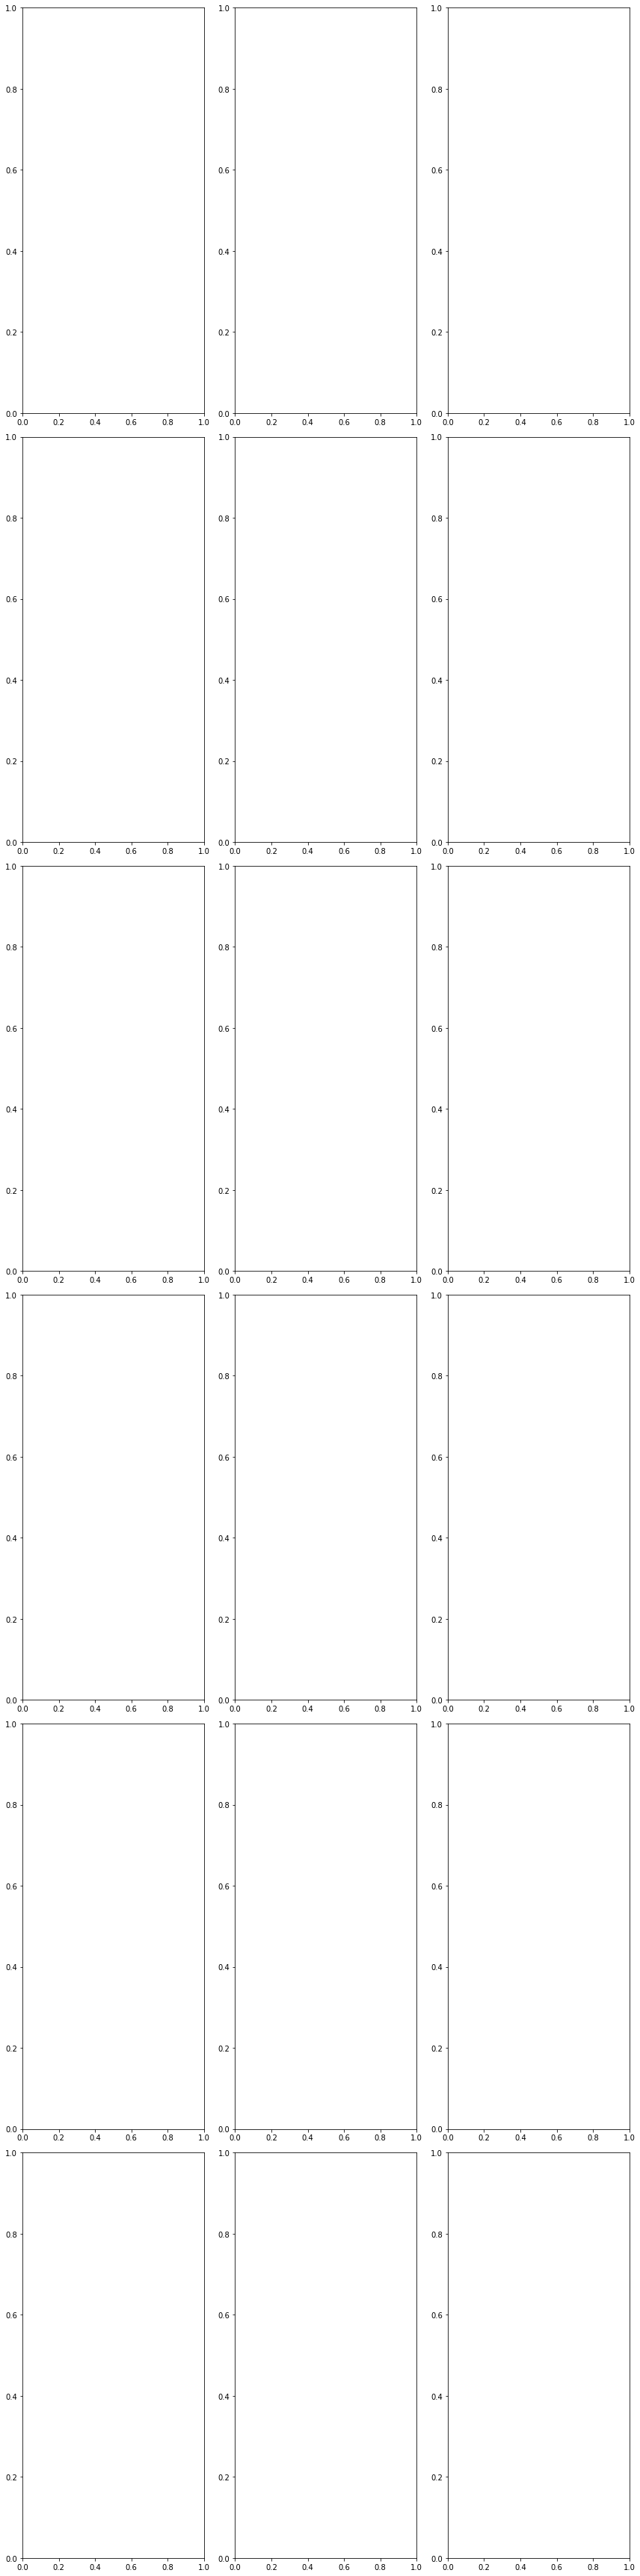

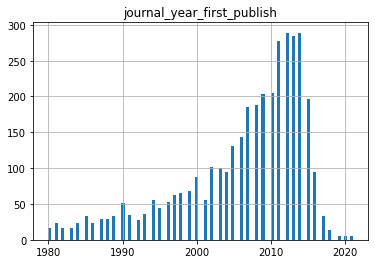

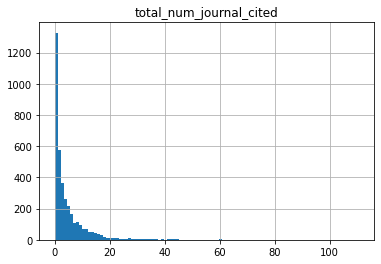

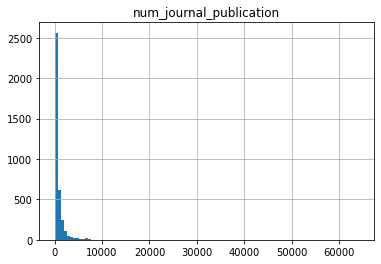

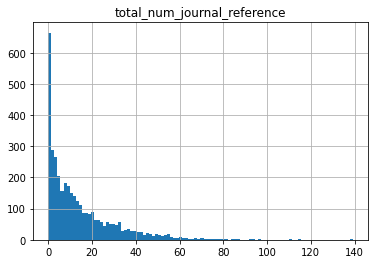

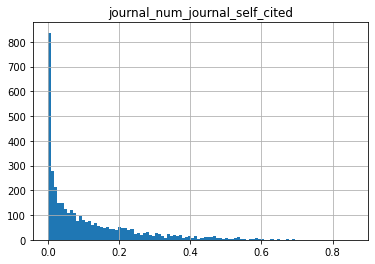

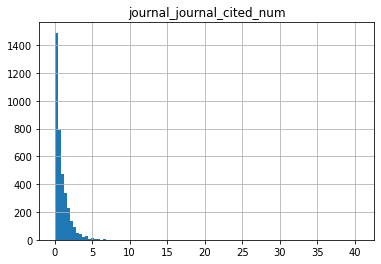

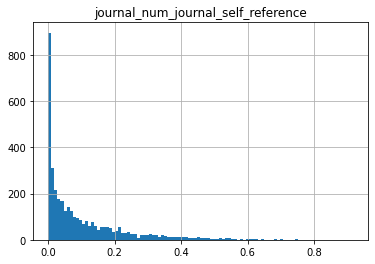

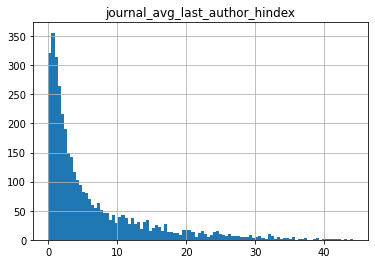

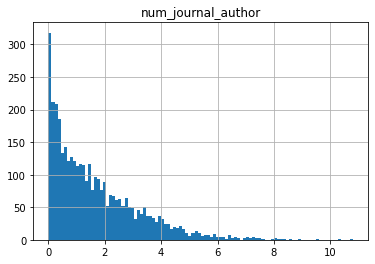

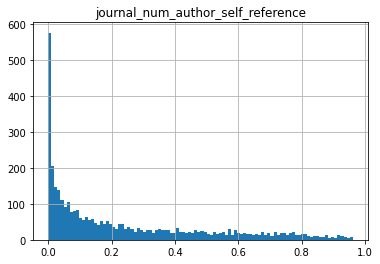

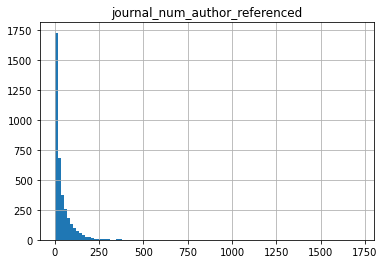

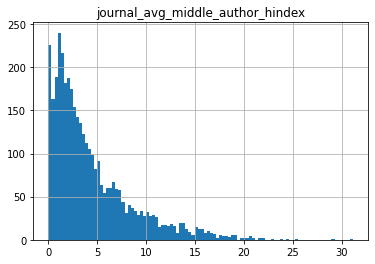

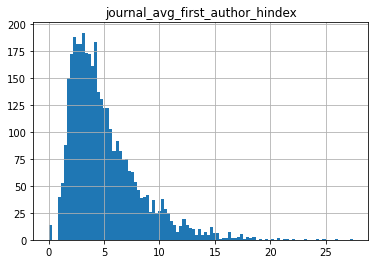

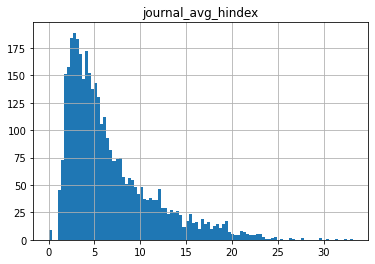

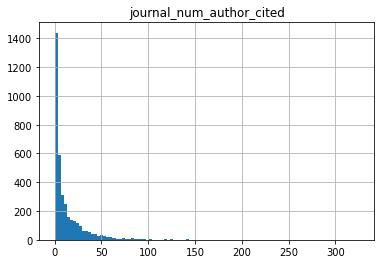

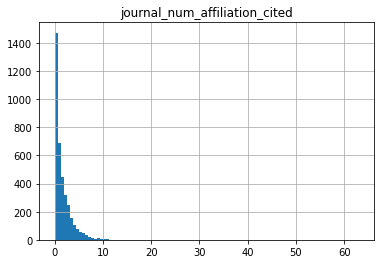

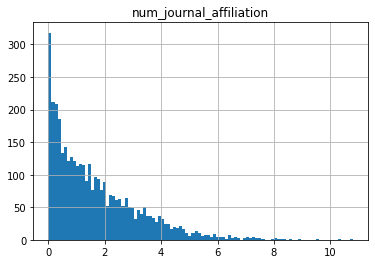

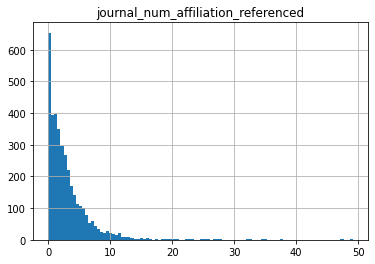

In [34]:
fig, axes = plt.subplots(len(bibilometrics_to_check.columns) // 3, 3, figsize=(12, 48))
for x in bibilometrics_after_average.columns:
    if x != 'Reason' and x != 'NormalizedName':
        bibilometrics_after_average.hist(column = x, bins = 100)

fig.tight_layout()

In [35]:
a = ['JournalId','NormalizedName','Issn','Reason','journal_year_first_publish',
                               'total_num_journal_cited','num_journal_publication','total_num_journal_reference','journal_num_journal_self_cited',
                              'journal_journal_cited_num','journal_paper_reference_num','journal_num_journal_self_reference',
                              'journal_avg_last_author_hindex','journal_num_author_self_cited',
                              'num_journal_author','journal_num_author_self_reference','journal_num_author_referenced',
                               'journal_avg_middle_author_hindex','journal_avg_first_author_hindex','journal_avg_hindex',
                               'journal_num_author_cited','journal_num_affiliation_cited','journal_num_affiliation_self_cited',
                               'num_journal_affiliation','journal_num_affiliation_referenced','journal_num_affiliation_self_reference'
                              ]

In [36]:
bibilometrics_to_check['total_num_journal_reference']

0         90
1       9397
2        778
3         12
5        509
        ... 
4425     132
4426     346
4427     847
4428      46
4429      23
Name: total_num_journal_reference, Length: 3728, dtype: int64

In [37]:
white_bib = bibilometrics_after_average[bibilometrics_after_average['Reason'] == 'Still in DOAJ index'].drop(columns=['Reason','NormalizedName'])
white_bib['label'] = 0
unwhite_bib = bibilometrics_after_average[bibilometrics_after_average['Reason'] != 'Still in DOAJ index'].drop(columns=['Reason','NormalizedName'])
unwhite_bib['label'] = 1

In [38]:
lr_tb = pd.concat([unwhite_bib,white_bib]).reset_index(drop=True)

In [39]:
X2 = lr_tb.loc[:, lr_tb.columns != 'label']
y2 = lr_tb.loc[:, lr_tb.columns == 'label']

In [40]:
X2_fit = preprocessing.StandardScaler().fit(X2).transform(X2.copy())

NameError: name 'preprocessing' is not defined

In [41]:
X2_df = pd.DataFrame(X2_fit,columns = X2.columns)

NameError: name 'X2_fit' is not defined

In [46]:
X2_df

,journal_year_first_publish,total_num_journal_cited,num_journal_publication,total_num_journal_reference,journal_num_journal_self_cited,journal_journal_cited_num,journal_num_journal_self_reference,journal_avg_last_author_hindex,num_journal_author,journal_num_author_self_reference,journal_num_author_referenced,journal_avg_middle_author_hindex,journal_avg_first_author_hindex,journal_avg_hindex,journal_num_author_cited,journal_num_affiliation_cited,num_journal_affiliation,journal_num_affiliation_referenced
0,-1.308499,-0.554331,-0.090121,-0.919190,-0.805380,-0.610478,-0.770681,-0.743911,-1.077092,-0.937076,-0.675906,-0.808290,-0.905914,-0.930527,-0.610564,-0.652505,-1.077092,-0.836502
1,-0.603283,0.418718,0.356612,-0.365889,0.125281,-0.070377,-0.041991,-0.261908,0.051062,0.472079,-0.370057,0.062184,0.242376,0.257317,0.337416,-0.025278,0.051062,-0.504277
2,-2.366324,-0.082866,0.295154,-0.262847,0.151982,-0.262896,0.177236,-0.421137,0.094426,0.011097,-0.288434,-0.557274,-0.736232,-0.582895,-0.114036,-0.433286,0.094426,-0.474010
3,-1.073427,0.562883,1.001705,0.009807,0.263671,0.235117,0.413255,0.213789,0.640010,0.133432,0.178947,-0.124258,0.034769,0.124996,0.990218,-0.114249,0.640010,-0.501569
4,-2.601396,0.183172,-0.107923,-0.733550,-0.533194,-0.319526,-0.458265,-0.652967,-0.462091,-0.303422,-0.615863,-0.802401,-0.652501,-0.764518,-0.138458,-0.495556,-0.462091,-0.690427
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3724,-0.720819,-0.504862,0.032370,-0.899413,-0.828383,-0.380274,-0.782336,-0.564206,-1.047141,-0.912253,-0.646722,-0.517474,-0.335650,-0.457680,-0.464923,-0.564222,-1.047141,-0.723466
3725,0.807150,-0.553919,-0.293143,-0.744356,-0.784090,-0.451995,-0.737450,-0.751487,-0.531226,-0.867927,-0.521422,-0.783534,-0.557482,-0.637401,-0.542413,-0.580595,-0.531226,-0.329660
3726,-0.133138,-0.569002,-0.136321,-0.865818,-0.828383,-0.566408,-0.782336,-0.614209,-1.036397,-0.872297,-0.636036,-0.558864,-0.685976,-0.345600,-0.592232,-0.616067,-1.036397,-0.698928
3727,0.689614,-0.589807,-0.329170,-0.190629,-0.738730,-0.579969,-0.691482,-0.678504,0.325700,-0.843767,-0.049907,-0.789783,-1.062396,-0.778442,-0.599483,-0.631159,0.325700,1.122436


In [47]:
X2_lr = X2_df.copy()
X2_lr['questionable'] = y2

In [48]:
X2_lr

,journal_year_first_publish,total_num_journal_cited,num_journal_publication,total_num_journal_reference,journal_num_journal_self_cited,journal_journal_cited_num,journal_num_journal_self_reference,journal_avg_last_author_hindex,num_journal_author,journal_num_author_self_reference,journal_num_author_referenced,journal_avg_middle_author_hindex,journal_avg_first_author_hindex,journal_avg_hindex,journal_num_author_cited,journal_num_affiliation_cited,num_journal_affiliation,journal_num_affiliation_referenced,questionable
0,-1.308499,-0.554331,-0.090121,-0.919190,-0.805380,-0.610478,-0.770681,-0.743911,-1.077092,-0.937076,-0.675906,-0.808290,-0.905914,-0.930527,-0.610564,-0.652505,-1.077092,-0.836502,1
1,-0.603283,0.418718,0.356612,-0.365889,0.125281,-0.070377,-0.041991,-0.261908,0.051062,0.472079,-0.370057,0.062184,0.242376,0.257317,0.337416,-0.025278,0.051062,-0.504277,1
2,-2.366324,-0.082866,0.295154,-0.262847,0.151982,-0.262896,0.177236,-0.421137,0.094426,0.011097,-0.288434,-0.557274,-0.736232,-0.582895,-0.114036,-0.433286,0.094426,-0.474010,1
3,-1.073427,0.562883,1.001705,0.009807,0.263671,0.235117,0.413255,0.213789,0.640010,0.133432,0.178947,-0.124258,0.034769,0.124996,0.990218,-0.114249,0.640010,-0.501569,1
4,-2.601396,0.183172,-0.107923,-0.733550,-0.533194,-0.319526,-0.458265,-0.652967,-0.462091,-0.303422,-0.615863,-0.802401,-0.652501,-0.764518,-0.138458,-0.495556,-0.462091,-0.690427,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3724,-0.720819,-0.504862,0.032370,-0.899413,-0.828383,-0.380274,-0.782336,-0.564206,-1.047141,-0.912253,-0.646722,-0.517474,-0.335650,-0.457680,-0.464923,-0.564222,-1.047141,-0.723466,0
3725,0.807150,-0.553919,-0.293143,-0.744356,-0.784090,-0.451995,-0.737450,-0.751487,-0.531226,-0.867927,-0.521422,-0.783534,-0.557482,-0.637401,-0.542413,-0.580595,-0.531226,-0.329660,0
3726,-0.133138,-0.569002,-0.136321,-0.865818,-0.828383,-0.566408,-0.782336,-0.614209,-1.036397,-0.872297,-0.636036,-0.558864,-0.685976,-0.345600,-0.592232,-0.616067,-1.036397,-0.698928,0
3727,0.689614,-0.589807,-0.329170,-0.190629,-0.738730,-0.579969,-0.691482,-0.678504,0.325700,-0.843767,-0.049907,-0.789783,-1.062396,-0.778442,-0.599483,-0.631159,0.325700,1.122436,0


In [49]:
my_formula = "questionable ~ " + " + ".join([col.replace(' ','_')for col in X2_lr.columns[:-1]])

In [52]:
reg2 = smf.logit(my_formula,X2_lr).fit()

Optimization terminated successfully.
         Current function value: 0.488348
         Iterations 11


In [53]:
print(reg2.summary())

                           Logit Regression Results                           
Dep. Variable:           questionable   No. Observations:                 3729
Model:                          Logit   Df Residuals:                     3711
Method:                           MLE   Df Model:                           17
Date:                Thu, 17 Apr 2025   Pseudo R-squ.:                  0.1328
Time:                        12:26:35   Log-Likelihood:                -1821.1
converged:                       True   LL-Null:                       -2100.0
Covariance Type:            nonrobust   LLR p-value:                1.190e-107
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Intercept                             -1.4835      0.056    -26.704      0.000      -1.592      -1.375
journal_year_first_publish             0.0498      0.046   

In [108]:
#print(reg2.summary())

                           Logit Regression Results                           
Dep. Variable:           questionable   No. Observations:                 3729
Model:                          Logit   Df Residuals:                     3711
Method:                           MLE   Df Model:                           17
Date:                Tue, 25 Jul 2023   Pseudo R-squ.:                  0.1328
Time:                        16:24:26   Log-Likelihood:                -1821.1
converged:                       True   LL-Null:                       -2100.0
Covariance Type:            nonrobust   LLR p-value:                1.190e-107
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Intercept                             -1.4835      0.056    -26.704      0.000      -1.592      -1.375
journal_year_first_publish             0.0498      0.046   

In [57]:
stargazer_tab2 = Stargazer([reg2])

In [111]:
open('regression2.html', 'w').write(stargazer_tab2.render_html())

3991

In [54]:
all_tb = pd.concat([unwhite_bib,white_bib]).reset_index(drop=True)

X6 = all_tb.loc[:, all_tb.columns != 'label']
y6 = all_tb.loc[:, all_tb.columns == 'label']

In [55]:
all_tb.shape

(3729, 19)

In [56]:
clf = RandomForestClassifier(max_depth=20,n_estimators = 500, random_state=0)

In [57]:
clf.fit(X6,y6)

<ipython-input-57-a264d11f1d61>:1: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  clf.fit(X6,y6)


RandomForestClassifier(max_depth=20, n_estimators=500, random_state=0)

In [58]:
clf.feature_importances_

array([0.07403103, 0.0497933 , 0.06124856, 0.05021137, 0.05995391,
       0.05708332, 0.05452698, 0.06228564, 0.05587952, 0.05446955,
       0.04639966, 0.06861486, 0.04712017, 0.05153013, 0.05157671,
       0.05465598, 0.0558947 , 0.04472461])

In [59]:
clf.feature_importances_

array([0.07403103, 0.0497933 , 0.06124856, 0.05021137, 0.05995391,
       0.05708332, 0.05452698, 0.06228564, 0.05587952, 0.05446955,
       0.04639966, 0.06861486, 0.04712017, 0.05153013, 0.05157671,
       0.05465598, 0.0558947 , 0.04472461])

<ipython-input-60-a456f11139c0>:12: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  classifier.fit(X6.iloc[train], y6.iloc[train])
<ipython-input-60-a456f11139c0>:12: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  classifier.fit(X6.iloc[train], y6.iloc[train])
<ipython-input-60-a456f11139c0>:12: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  classifier.fit(X6.iloc[train], y6.iloc[train])
<ipython-input-60-a456f11139c0>:12: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  classifier.fit(X6.iloc[train], y6.iloc[train])
<ipython-input-60-a456f11139c0>:12: Data

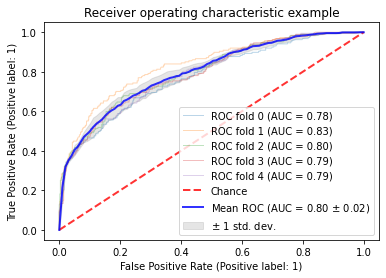

In [60]:
cv = StratifiedKFold(n_splits=5,random_state = 611,shuffle=True)
#classifier = svm.SVC( random_state=5)
#classifier = LogisticRegression(random_state=5)
#classifier = LogisticRegressionCV(random_state=5)
classifier = RandomForestClassifier(max_depth=20,n_estimators = 500, random_state=0)
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

fig, ax = plt.subplots()
for i, (train, test) in enumerate(cv.split(X6, y6)):
    classifier.fit(X6.iloc[train], y6.iloc[train])
    viz = RocCurveDisplay.from_estimator(
        classifier,
        X6.iloc[test],
        y6.iloc[test],
        name="ROC fold {}".format(i),
        alpha=0.3,
        lw=1,
        ax=ax,
    )
    interp_tpr = np.interp(mean_fpr, viz.fpr, viz.tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    aucs.append(viz.roc_auc)

ax.plot([0, 1], [0, 1], linestyle="--", lw=2, color="r", label="Chance", alpha=0.8)

mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)
ax.plot(
    mean_fpr,
    mean_tpr,
    color="b",
    label=r"Mean ROC (AUC = %0.2f $\pm$ %0.2f)" % (mean_auc, std_auc),
    lw=2,
    alpha=0.8,
)

std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
ax.fill_between(
    mean_fpr,
    tprs_lower,
    tprs_upper,
    color="grey",
    alpha=0.2,
    label=r"$\pm$ 1 std. dev.",
)

ax.set(
    xlim=[-0.05, 1.05],
    ylim=[-0.05, 1.05],
    title="Receiver operating characteristic example",
)
ax.legend(loc="lower right")
plt.show()

<ipython-input-61-a10fdbacf979>:12: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  classifier.fit(X6.iloc[train], y6.iloc[train])
<ipython-input-61-a10fdbacf979>:12: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  classifier.fit(X6.iloc[train], y6.iloc[train])
<ipython-input-61-a10fdbacf979>:12: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  classifier.fit(X6.iloc[train], y6.iloc[train])
<ipython-input-61-a10fdbacf979>:12: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  classifier.fit(X6.iloc[train], y6.iloc[train])
<ipython-input-61-a10fdbacf979>:12: Data

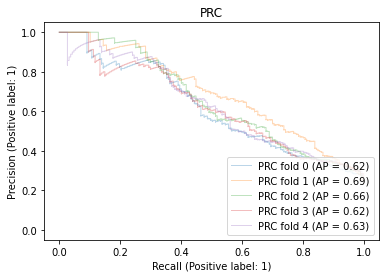

In [61]:
cv = StratifiedKFold(n_splits=5,random_state = 611,shuffle=True)
#classifier = svm.SVC( random_state=5)
#classifier = LogisticRegression(random_state=5)
#classifier = LogisticRegressionCV(random_state=5)
classifier = RandomForestClassifier(max_depth=20,n_estimators = 500, random_state=0,n_jobs=6)
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

fig, ax = plt.subplots()
for i, (train, test) in enumerate(cv.split(X6, y6)):
    classifier.fit(X6.iloc[train], y6.iloc[train])
    viz = PrecisionRecallDisplay.from_estimator(
        classifier,
        X6.iloc[test],
        y6.iloc[test],
        name="PRC fold {}".format(i),
        alpha=0.3,
        lw=1,
        ax=ax,
    )
    #interp_tpr = np.interp(mean_fpr, viz.fpr, viz.tpr)
    #interp_tpr[0] = 0.0
    #tprs.append(interp_tpr)
    #aucs.append(viz.roc_auc)



ax.set(
    xlim=[-0.05, 1.05],
    ylim=[-0.05, 1.05],
    title="PRC",
)
ax.legend(loc="lower right")
plt.show()

In [65]:
np.mean([0.62,0.69,0.66,0.62,0.63])

0.644

In [66]:
np.std([0.62,0.69,0.66,0.62,0.63])

0.0272763633939717

# Predict unpaywall with bibliometric features

In [42]:
import pandas as pd

In [43]:
journal_info = pd.read_csv('..\\data\\doaj_journal_list_urls_from_doaj_bing_v1.csv')

In [44]:
journal_info.shape

(15395, 11)

In [47]:
unpaywall_bib_features_0 = pd.read_csv('..\\data\\unpaywall_journals_biblio_features_v1.csv')

In [48]:
unpaywall_bib_features_0.shape

(25348, 27)

In [5]:
unpaywall_bib_features = unpaywall_bib_features_0[~unpaywall_bib_features_0['NormalizedName'].isin(journal_info['Journal_Title_Normalized'])]

In [6]:
unpaywall_bib_features.head(5)

,JournalId,Issn,NormalizedName,num_journal_publication,num_journal_author,num_journal_affiliation,journal_year_first_publish,journal_avg_hindex,journal_avg_first_author_hindex,journal_avg_last_author_hindex,...,journal_num_author_referenced,journal_num_author_cited,journal_num_affiliation_referenced,journal_num_affiliation_cited,journal_num_journal_self_reference,journal_num_author_self_reference,journal_num_affiliation_self_reference,journal_num_journal_self_cited,journal_num_author_self_cited,journal_num_affiliation_self_cited
0,161399637,1015-8987,cellular physiology and biochemistry,5954,24816,24816,1991,10.046757,5.605793,15.583137,...,536200,430505,5809,5929,2741,3253,2935,2694,3383,3170
1,47727624,0165-5701,international ophthalmology,4193,12322,12322,1978,7.421600,5.557528,8.626282,...,166566,84772,3947,3380,897,1445,1200,850,916,769
2,160779208,0021-9002,journal of applied probability,5390,5327,5327,1964,6.816621,6.514822,4.815399,...,27734,74518,1970,4431,3103,2469,748,2436,2367,709
3,22232893,1759-4758,nature reviews neurology,2931,3786,3786,2005,23.631601,20.509513,25.391675,...,297086,345246,5152,6364,525,1386,1233,486,990,912
4,200416800,1868-7075,clinical epigenetics,1283,9668,9668,2010,20.884199,8.004281,31.024162,...,255591,100694,4758,3792,603,1134,1125,547,771,773


In [7]:
unpaywall_bib_features.shape

(22501, 27)

In [8]:
to_average = ['num_journal_author','num_journal_affiliation','total_num_journal_reference',
              'total_num_journal_cited','journal_journal_cited_num',
              'journal_num_author_referenced','journal_num_affiliation_referenced','journal_num_author_cited',
              'journal_num_affiliation_cited','journal_num_journal_self_reference','journal_num_author_self_reference',
              'journal_num_affiliation_self_reference','journal_num_journal_self_cited','journal_journal_cited_num'
             ]

In [9]:
to_ignore = ['journal_paper_cited','journal_journal_reference','journal_num_affiliation_self_reference','journal_num_author_self_cited','journal_num_affiliation_self_cited']

In [10]:
all_features = ['JournalId','journal_year_first_publish','NormalizedName',
                               'total_num_journal_cited','num_journal_publication','total_num_journal_reference','journal_num_journal_self_cited',
                              'journal_journal_cited_num','journal_num_journal_self_reference',
                              'journal_avg_last_author_hindex','journal_num_author_self_cited',
                              'num_journal_author','journal_num_author_self_reference','journal_num_author_referenced',
                               'journal_avg_middle_author_hindex','journal_avg_first_author_hindex','journal_avg_hindex',
                               'journal_num_author_cited','journal_num_affiliation_cited','journal_num_affiliation_self_cited',
                               'num_journal_affiliation','journal_num_affiliation_referenced','journal_num_affiliation_self_reference'
                              ]
features_to_use = [f for f in all_features if f not in to_ignore] 

In [11]:
unpaywall_bib_features

,JournalId,Issn,NormalizedName,num_journal_publication,num_journal_author,num_journal_affiliation,journal_year_first_publish,journal_avg_hindex,journal_avg_first_author_hindex,journal_avg_last_author_hindex,...,journal_num_author_referenced,journal_num_author_cited,journal_num_affiliation_referenced,journal_num_affiliation_cited,journal_num_journal_self_reference,journal_num_author_self_reference,journal_num_affiliation_self_reference,journal_num_journal_self_cited,journal_num_author_self_cited,journal_num_affiliation_self_cited
0,161399637,1015-8987,cellular physiology and biochemistry,5954,24816,24816,1991,10.046757,5.605793,15.583137,...,536200,430505,5809,5929,2741,3253,2935,2694,3383,3170
1,47727624,0165-5701,international ophthalmology,4193,12322,12322,1978,7.421600,5.557528,8.626282,...,166566,84772,3947,3380,897,1445,1200,850,916,769
2,160779208,0021-9002,journal of applied probability,5390,5327,5327,1964,6.816621,6.514822,4.815399,...,27734,74518,1970,4431,3103,2469,748,2436,2367,709
3,22232893,1759-4758,nature reviews neurology,2931,3786,3786,2005,23.631601,20.509513,25.391675,...,297086,345246,5152,6364,525,1386,1233,486,990,912
4,200416800,1868-7075,clinical epigenetics,1283,9668,9668,2010,20.884199,8.004281,31.024162,...,255591,100694,4758,3792,603,1134,1125,547,771,773
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25343,58951593,1082-7579,medical update for psychiatrists,101,139,139,1996,4.606944,4.434783,2.128713,...,6439,341,495,88,7,16,22,7,9,12
25344,2764664074,2155-6199,journal of bioremediation and biodegradation,497,801,801,2010,6.884111,3.931034,4.070423,...,19032,11916,1918,1764,23,94,5,39,105,1
25345,2898386384,2452-1760,advances in ophthalmology and optometry,147,312,312,2016,10.727299,8.333333,9.353741,...,25249,478,1623,127,5,54,48,4,11,7
25346,2764986136,2055-1266,journal of biomedical engineering and medical ...,182,222,222,2014,5.347269,2.857143,3.005495,...,5276,809,897,236,11,24,20,12,29,25


In [12]:
unpaywall_bib_features = unpaywall_bib_features[unpaywall_bib_features['journal_paper_reference_num'] != 0]

In [13]:
unpaywall_bib_features2 = unpaywall_bib_features[unpaywall_bib_features['num_journal_author'] != 0]

In [14]:
unpaywall_bib_features3 = unpaywall_bib_features2[unpaywall_bib_features2['num_journal_publication']>10]

In [15]:
unpaywall_bib_features3[unpaywall_bib_features3['journal_num_affiliation_referenced'] == 0]

,JournalId,Issn,NormalizedName,num_journal_publication,num_journal_author,num_journal_affiliation,journal_year_first_publish,journal_avg_hindex,journal_avg_first_author_hindex,journal_avg_last_author_hindex,...,journal_num_author_referenced,journal_num_author_cited,journal_num_affiliation_referenced,journal_num_affiliation_cited,journal_num_journal_self_reference,journal_num_author_self_reference,journal_num_affiliation_self_reference,journal_num_journal_self_cited,journal_num_author_self_cited,journal_num_affiliation_self_cited


In [16]:
unpaywall_bib_features3[unpaywall_bib_features3['num_journal_affiliation'] == 0]

,JournalId,Issn,NormalizedName,num_journal_publication,num_journal_author,num_journal_affiliation,journal_year_first_publish,journal_avg_hindex,journal_avg_first_author_hindex,journal_avg_last_author_hindex,...,journal_num_author_referenced,journal_num_author_cited,journal_num_affiliation_referenced,journal_num_affiliation_cited,journal_num_journal_self_reference,journal_num_author_self_reference,journal_num_affiliation_self_reference,journal_num_journal_self_cited,journal_num_author_self_cited,journal_num_affiliation_self_cited


In [17]:
unpaywall_bib_features0 = unpaywall_bib_features3[features_to_use].copy()
unpaywall_bib_features_to_check = unpaywall_bib_features0[unpaywall_bib_features0['journal_year_first_publish']>=1980]

In [18]:
def my_log(num):
    return np.log(1+num)

In [19]:
unpaywall_bib_features_to_check.shape

(15191, 20)

In [20]:
unpaywall_bib_features_after_average = unpaywall_bib_features_to_check.copy()

In [21]:
unpaywall_bib_features_after_average

,JournalId,journal_year_first_publish,NormalizedName,total_num_journal_cited,num_journal_publication,total_num_journal_reference,journal_num_journal_self_cited,journal_journal_cited_num,journal_num_journal_self_reference,journal_avg_last_author_hindex,num_journal_author,journal_num_author_self_reference,journal_num_author_referenced,journal_avg_middle_author_hindex,journal_avg_first_author_hindex,journal_avg_hindex,journal_num_author_cited,journal_num_affiliation_cited,num_journal_affiliation,journal_num_affiliation_referenced
0,161399637,1991,cellular physiology and biochemistry,130983,5954,203586,2694,5118,2741,15.583137,24816,3253,536200,6.993325,5.605793,10.046757,430505,5929,24816,5809
3,22232893,2005,nature reviews neurology,114934,2931,106349,486,5897,525,25.391675,3786,1386,297086,28.747948,20.509513,23.631601,345246,6364,3786,5152
4,200416800,2010,clinical epigenetics,26667,1283,75719,547,2745,603,31.024162,9668,1134,255591,19.856783,8.004281,20.884199,100694,3792,9668,4758
6,194129668,1991,bird conservation international,15812,1103,27288,493,1095,539,8.543971,3270,665,36119,5.709412,6.140863,7.954233,30532,2398,3270,2289
7,177423656,2000,thermal science,24812,4416,42816,1324,1804,1295,5.761096,7647,1220,67337,4.455007,5.780712,7.385276,41224,3235,7647,3874
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25342,2764480751,2004,the journal of asian philosophy in korea,2,344,28,0,1,0,0.020349,12,0,26,0.000000,7.000000,7.000000,2,2,12,11
25343,58951593,1996,medical update for psychiatrists,129,101,1851,7,74,7,2.128713,139,16,6439,3.651515,4.434783,4.606944,341,88,139,495
25344,2764664074,2010,journal of bioremediation and biodegradation,4019,497,7150,39,736,23,4.070423,801,94,19032,3.723297,3.931034,6.884111,11916,1764,801,1918
25345,2898386384,2016,advances in ophthalmology and optometry,113,147,6627,4,65,5,9.353741,312,54,25249,6.321259,8.333333,10.727299,478,127,312,1623


In [22]:
for x in unpaywall_bib_features_after_average.columns:
    if x in to_average:
        unpaywall_bib_features_after_average[x] = unpaywall_bib_features_after_average[x]/unpaywall_bib_features_after_average['num_journal_publication']

In [23]:
for x in unpaywall_bib_features_after_average.columns:
    print(x)
    print(min(unpaywall_bib_features_after_average[x]))

JournalId
61661
journal_year_first_publish
1980
NormalizedName
3c empresa
total_num_journal_cited
0.0
num_journal_publication
11
total_num_journal_reference
0.00023929169657812874
journal_num_journal_self_cited
0.0
journal_journal_cited_num
0.0
journal_num_journal_self_reference
0.0
journal_avg_last_author_hindex
0.0
num_journal_author
0.00023929169657812874
journal_num_author_self_reference
0.0
journal_num_author_referenced
0.00023929169657812874
journal_avg_middle_author_hindex
0.0
journal_avg_first_author_hindex
0.0
journal_avg_hindex
0.0
journal_num_author_cited
0.0
journal_num_affiliation_cited
0.0
num_journal_affiliation
0.00023929169657812874
journal_num_affiliation_referenced
0.000177999288002848


In [49]:
bibilometrics_after_average = pd.read_csv('..\\data\\doaj_bibilometrics_after_average_v1.csv')

In [50]:
bibilometrics_after_average

,Reason,NormalizedName,journal_year_first_publish,total_num_journal_cited,num_journal_publication,total_num_journal_reference,journal_num_journal_self_cited,journal_journal_cited_num,journal_num_journal_self_reference,journal_avg_last_author_hindex,num_journal_author,journal_num_author_self_reference,journal_num_author_referenced,journal_avg_middle_author_hindex,journal_avg_first_author_hindex,journal_avg_hindex,journal_num_author_cited,journal_num_affiliation_cited,num_journal_affiliation,journal_num_affiliation_referenced
0,Still in DOAJ index,3c tic,2012,0.470000,200,0.450000,0.000000,0.140000,0.000000,0.645000,0.295000,0.015000,1.225000,0.617424,2.423077,2.481504,1.245000,0.265000,0.295000,0.200000
1,Still in DOAJ index,aace clinical case reports,2014,0.926493,653,14.390505,0.062787,0.428790,0.070444,12.782542,3.764165,0.134763,59.707504,6.743214,4.981982,10.629954,4.303216,0.856049,3.764165,2.949464
2,Still in DOAJ index,aaps open,2015,5.970588,34,22.882353,0.088235,2.764706,0.088235,7.794118,4.647059,0.441176,88.852941,7.119501,6.000000,9.055016,25.500000,7.470588,4.647059,14.441176
3,Still in DOAJ index,abril,2008,0.065217,46,0.260870,0.000000,0.021739,0.000000,0.217391,0.065217,0.000000,0.304348,0.333333,2.800000,1.928571,0.043478,0.043478,0.065217,0.108696
4,Still in DOAJ index,accounting analysis journal,2012,1.351124,356,1.429775,0.028090,0.182584,0.019663,0.825843,0.328652,0.002809,1.991573,0.413793,1.352941,1.652174,2.550562,0.205056,0.328652,0.396067
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3724,Journal not adhering to Best Practice,žurnal nano- ta elektronnoï fìziki,2009,1.174391,1273,0.103692,0.000000,0.276512,0.000000,2.925373,0.220738,0.002357,0.190102,2.839471,4.705600,5.265144,3.400628,0.604085,0.220738,0.030636
3725,Journal not adhering to Best practice,анали мечниківського інституту,2012,0.148148,81,4.271605,0.000000,0.098765,0.000000,0.049383,1.098765,0.000000,28.975309,0.050314,3.666667,2.700000,0.790123,0.209877,1.098765,4.641975
3726,Journal not adhering to Best practice,вестник международных организаций: образование...,2006,1.788714,762,1.111549,0.022310,0.574803,0.007874,1.266404,0.137795,0.015748,1.640420,1.277965,4.658879,4.819471,3.417323,0.891076,0.137795,0.316273
3727,Journal not adhering to Best practice,вопросы регулирования экономики,2015,0.428571,35,1.314286,0.000000,0.171429,0.000000,0.085714,0.285714,0.000000,2.342857,0.000000,1.000000,1.000000,1.142857,0.228571,0.285714,0.885714


In [26]:
white_bib = bibilometrics_after_average[bibilometrics_after_average['Reason'] == 'Still in DOAJ index'].drop(columns=['Reason','NormalizedName'])
white_bib['label'] = 0
unwhite_bib = bibilometrics_after_average[bibilometrics_after_average['Reason'] != 'Still in DOAJ index'].drop(columns=['Reason','NormalizedName'])
unwhite_bib['label'] = 1

In [27]:
all_tb = pd.concat([unwhite_bib,white_bib]).reset_index(drop=True)

X6 = all_tb.loc[:, all_tb.columns != 'label']
y6 = all_tb.loc[:, all_tb.columns == 'label']

In [28]:
#X_unpay = unpaywall_bib_features_after_average.loc[:, unpaywall_bib_features_after_average.columns != 'NormalizedName']
X_unpay = unpaywall_bib_features_after_average.drop(columns=['JournalId','NormalizedName'])

In [29]:
X_unpay.shape

(15191, 18)

In [34]:
clf = RandomForestClassifier(max_depth=20,n_estimators = 500, random_state=0)

In [35]:
clf.fit(X6,y6)

<ipython-input-35-a264d11f1d61>:1: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  clf.fit(X6,y6)


RandomForestClassifier(max_depth=20, n_estimators=500, random_state=0)

In [36]:
res_pd = unpaywall_bib_features_after_average[clf.predict_proba(X_unpay)[:,1]>0.5][['JournalId']] # .to_csv('questionable_journal_detected_v1_final.csv',index=False)

In [37]:
unpaywall_bib_features_after_average['Predicted_Probability'] = clf.predict_proba(X_unpay)[:,1]

In [38]:
unpaywall_bib_features_after_average.to_csv('Unpaywall_predictions_all.csv',index=False)

In [40]:
res_pd = res_pd.merge(unpaywall_bib_features_after_average[['JournalId','Predicted_Probability']],
                      on=['JournalId'])

In [41]:
res_pd

,JournalId,Predicted_Probability
0,151544878,0.596406
1,22786342,0.546000
2,2764569163,0.712889
3,2764909137,0.569968
4,2764572829,0.751823
...,...,...
1432,2764485898,0.573204
1433,2737539742,0.665949
1434,2764613678,0.592989
1435,136940034,0.738000


# After scrape journal websites and extract website html tag, you can run the code below to train and validate on DOAJ journals

In [67]:
tag_features1 = []
tag_features0 = []

for batch in range(100):
    #labeled_feature_data_local_html_v1
    with open('labeled_journal_feature_2024\\web_tag_features_1_'+str(batch)+'.pkl', 'rb') as f:
        tag_features1 += pickle.load(f)

    with open('labeled_journal_feature_2024\\web_tag_features_0_'+str(batch)+'.pkl', 'rb') as f:
        tag_features0 += pickle.load(f)

print('tag feature')
print(len(tag_features1))
#print(tag_features1)
print(len(tag_features0))
#print(tag_features0)

tag_features1 = [ft for ind,ft in enumerate(tag_features1) if len(ft) >1]
tag_features0 = [ft for ind,ft in enumerate(tag_features0) if len(ft) >1]

print(len(tag_features1))
print(len(tag_features0))

data = tag_features1 + tag_features0
label = [1 for ft in tag_features1] + [0 for ft in tag_features0]



vectorizer = TfidfVectorizer()
X2 = vectorizer.fit_transform(data)
y2 = np.array(label)

tag feature
2536
12859
2532
12791


In [68]:
classifier = RandomForestClassifier(max_depth=20,n_estimators = 500, random_state=0).fit(X2, y2)

In [78]:
term_weights = dict(zip(vectorizer.get_feature_names_out(), classifier.feature_importances_))

In [1]:
#scaler = preprocessing.StandardScaler().fit(X2)
lr = LogisticRegression(random_state=0,max_iter=1000).fit(X2, y2)


NameError: name 'LogisticRegression' is not defined

In [2]:
term_sign = dict(zip(vectorizer.get_feature_names_out(), lr.coef_[0]))

NameError: name 'vectorizer' is not defined

In [91]:
#classifier = RandomForestClassifier(max_depth=20,n_estimators = 500, random_state=0).fit(X2, y2)
#pickle.dump(classifier, open('webtag_classifer', 'wb'))

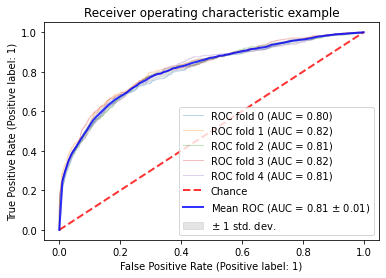

In [69]:
cv = StratifiedKFold(n_splits=5,random_state = 231,shuffle=True)
#classifier = svm.SVC( random_state=5)
#classifier = LogisticRegression(random_state=5)
#classifier = LogisticRegressionCV(random_state=5)
classifier = RandomForestClassifier(max_depth=20,n_estimators = 500, random_state=0,n_jobs=6)
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

fig, ax = plt.subplots()
for i, (train, test) in enumerate(cv.split(X2, y2)):
    classifier.fit(X2[train], y2[train])
    viz = RocCurveDisplay.from_estimator(
        classifier,
        X2[test],
        y2[test],
        name="ROC fold {}".format(i),
        alpha=0.3,
        lw=1,
        ax=ax,
    )
    interp_tpr = np.interp(mean_fpr, viz.fpr, viz.tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    aucs.append(viz.roc_auc)

ax.plot([0, 1], [0, 1], linestyle="--", lw=2, color="r", label="Chance", alpha=0.8)

mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)
ax.plot(
    mean_fpr,
    mean_tpr,
    color="b",
    label=r"Mean ROC (AUC = %0.2f $\pm$ %0.2f)" % (mean_auc, std_auc),
    lw=2,
    alpha=0.8,
)

std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
ax.fill_between(
    mean_fpr,
    tprs_lower,
    tprs_upper,
    color="grey",
    alpha=0.2,
    label=r"$\pm$ 1 std. dev.",
)

ax.set(
    xlim=[-0.05, 1.05],
    ylim=[-0.05, 1.05],
    title="Receiver operating characteristic example",
)
ax.legend(loc="lower right")
plt.show()

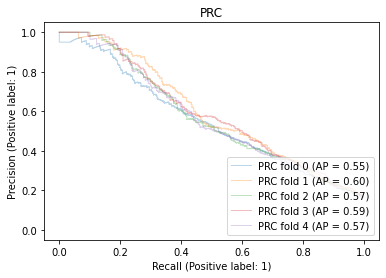

In [70]:
cv = StratifiedKFold(n_splits=5,random_state = 231,shuffle=True)
#classifier = svm.SVC( random_state=5)
#classifier = LogisticRegression(random_state=5)
#classifier = LogisticRegressionCV(random_state=5)
classifier = RandomForestClassifier(max_depth=20,n_estimators = 500, random_state=0,n_jobs=6)
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

fig, ax = plt.subplots()
for i, (train, test) in enumerate(cv.split(X2, y2)):
    classifier.fit(X2[train], y2[train])
    viz = PrecisionRecallDisplay.from_estimator(
        classifier,
        X2[test],
        y2[test],
        name="PRC fold {}".format(i),
        alpha=0.3,
        lw=1,
        ax=ax,
    )
    #interp_tpr = np.interp(mean_fpr, viz.fpr, viz.tpr)
    #interp_tpr[0] = 0.0
    #tprs.append(interp_tpr)
    #aucs.append(viz.roc_auc)



ax.set(
    xlim=[-0.05, 1.05],
    ylim=[-0.05, 1.05],
    title="PRC",
)
ax.legend(loc="lower right")
plt.show()

In [71]:
np.mean([0.55,0.60,0.57,0.59,0.57]),np.std([0.55,0.60,0.57,0.59,0.57])

(0.5759999999999998, 0.017435595774162677)

In [94]:
font_features1 = []
font_features0 = []

for batch in range(100):
    with open('./labeled_journal_feature_2022/web_font_features_1_'+str(batch)+'.pkl', 'rb') as f:
        font_features1 += pickle.load(f)

    with open('./labeled_journal_feature_2022/web_font_features_0_'+str(batch)+'.pkl', 'rb') as f:
        font_features0 += pickle.load(f)

print('font feature')
print(len(font_features1))
print(len(font_features0))
font_feature1 = [ft for ind,ft in enumerate(font_features1) if len(ft) > 0]
font_feature0 = [ft for ind,ft in enumerate(font_features0) if len(ft) > 0]
font_feature = font_feature1 + font_feature0
label = [1 for ft in font_feature1] + [0 for ft in font_feature0]

print(len(font_feature1))
print(len(font_feature0))

vectorizer = TfidfVectorizer()
X3 = vectorizer.fit_transform([' '.join(ff) for ff in font_feature])
y3 = np.array(label)

font feature
2567
12859
1725
10113


In [115]:
#pickle.dump(vectorizer, open('webfont_tfidf', 'wb'))

In [96]:
classifier = RandomForestClassifier(max_depth=20,n_estimators = 500, random_state=0).fit(X3, y3)
term_weights = dict(zip(vectorizer.get_feature_names_out(), classifier.feature_importances_))
#dict(sorted(term_weights.items(), key=lambda item: item[1]))

In [97]:
lr = LogisticRegression(random_state=0,max_iter=1000).fit(X3, y3)
lr.coef_

array([[-0.23688505, -0.14497993,  1.0388704 , ...,  0.01977095,
         0.13162415,  0.13162415]])

In [98]:
#term_sign = dict(zip(vectorizer.get_feature_names_out(), lr.coef_[0]))

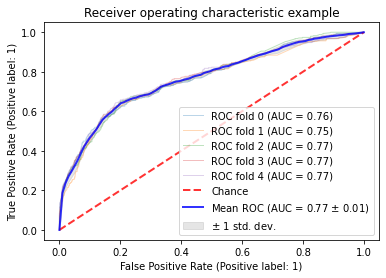

In [99]:
cv = StratifiedKFold(n_splits=5,random_state = 231,shuffle=True)
#classifier = svm.SVC( random_state=5)
#classifier = LogisticRegression(random_state=5)
#classifier = LogisticRegressionCV(random_state=5)
classifier = RandomForestClassifier(max_depth=20,n_estimators = 500, random_state=0)
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

fig, ax = plt.subplots()
for i, (train, test) in enumerate(cv.split(X3, y3)):
    classifier.fit(X3[train], y3[train])
    viz = RocCurveDisplay.from_estimator(
        classifier,
        X3[test],
        y3[test],
        name="ROC fold {}".format(i),
        alpha=0.3,
        lw=1,
        ax=ax,
    )
    interp_tpr = np.interp(mean_fpr, viz.fpr, viz.tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    aucs.append(viz.roc_auc)

ax.plot([0, 1], [0, 1], linestyle="--", lw=2, color="r", label="Chance", alpha=0.8)

mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)
ax.plot(
    mean_fpr,
    mean_tpr,
    color="b",
    label=r"Mean ROC (AUC = %0.2f $\pm$ %0.2f)" % (mean_auc, std_auc),
    lw=2,
    alpha=0.8,
)

std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
ax.fill_between(
    mean_fpr,
    tprs_lower,
    tprs_upper,
    color="grey",
    alpha=0.2,
    label=r"$\pm$ 1 std. dev.",
)

ax.set(
    xlim=[-0.05, 1.05],
    ylim=[-0.05, 1.05],
    title="Receiver operating characteristic example",
)
ax.legend(loc="lower right")
plt.show()

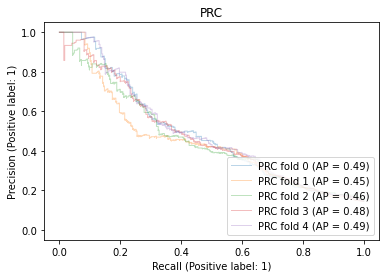

In [100]:
cv = StratifiedKFold(n_splits=5,random_state = 231,shuffle=True)
#classifier = svm.SVC( random_state=5)
#classifier = LogisticRegression(random_state=5)
#classifier = LogisticRegressionCV(random_state=5)
classifier = RandomForestClassifier(max_depth=20,n_estimators = 500, random_state=0,n_jobs=6)
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

fig, ax = plt.subplots()
for i, (train, test) in enumerate(cv.split(X3, y3)):
    classifier.fit(X3[train], y3[train])
    viz = PrecisionRecallDisplay.from_estimator(
        classifier,
        X3[test],
        y3[test],
        name="PRC fold {}".format(i),
        alpha=0.3,
        lw=1,
        ax=ax,
    )
    #interp_tpr = np.interp(mean_fpr, viz.fpr, viz.tpr)
    #interp_tpr[0] = 0.0
    #tprs.append(interp_tpr)
    #aucs.append(viz.roc_auc)



ax.set(
    xlim=[-0.05, 1.05],
    ylim=[-0.05, 1.05],
    title="PRC",
)
ax.legend(loc="lower right")
plt.show()

In [101]:
np.mean([0.49,0.45,0.46,0.48,0.49]),np.std([0.49,0.45,0.46,0.48,0.49])

(0.47400000000000003, 0.016248076809271907)

# Concate different features into one feature to predict

In [1]:
import pickle
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np

In [2]:
web_features1 = []
web_features0 = []

for batch in range(0,100):
    with open('labeled_journal_feature_2024\\web_content_features_1_'+str(batch)+'.pkl', 'rb') as f:
        web_features1 += pickle.load(f)

    with open('labeled_journal_feature_2024\\web_content_features_0_'+str(batch)+'.pkl', 'rb') as f:
        web_features0 += pickle.load(f)

In [3]:
tag_features1 = []
tag_features0 = []

for batch in range(100):
    with open('labeled_journal_feature_2024\\web_tag_features_1_'+str(batch)+'.pkl', 'rb') as f:
        tag_features1 += pickle.load(f)

    with open('labeled_journal_feature_2024\\web_tag_features_0_'+str(batch)+'.pkl', 'rb') as f:
        tag_features0 += pickle.load(f)

In [4]:
len(web_features1),len(web_features0),

(2536, 12859)

In [5]:
len(tag_features1),len(tag_features0),

(2536, 12859)

In [109]:
#use after average directly 
#drop two duplicated columns: save value but different column name
#bibilometrics = pd.read_csv('doaj_journals_biblio_features.csv').drop(columns=['journal_paper_cited_num','journal_journal_reference_num'])

#jump to here

In [6]:
labeled_journals = pd.read_csv('doaj_journal_list_urls_from_doaj_bing_v1.csv')

In [7]:
labeled_journals.head(3)

,Unnamed: 0,Journal_Title_Normalized,added,Journal Title,ISSN,Remove_Date,Add_Date,Reason,Data Source,URL,reason_category
0,0,"#tear: revista de educação, ciência e tecnologia",True,"#Tear: Revista de Educação, Ciência e Tecnologia",2238-8079,1677-09-22,2015-07-20,Still in DOAJ index,DOAJ,https://periodicos.ifrs.edu.br/index.php/tear/...,interesting reason
1,1,(en)clave comahue,True,(En)clave Comahue,2545-6466,1677-09-22,2019-05-13,Still in DOAJ index,DOAJ,http://revele.uncoma.edu.ar/htdoc/revele/index...,interesting reason
2,2,(پژوهش حسابداری و حسابرسی (پیوسته,True,(پژوهش حسابداری و حسابرسی (پیوسته,2676-7554,1677-09-22,2020-05-25,Still in DOAJ index,DOAJ,https://ijar.alzahra.ac.ir/,interesting reason


In [8]:
labeled_journals.shape

(15395, 11)

In [9]:
labeled_journals['ISSN'] = labeled_journals['ISSN'].apply(str.strip)

In [10]:
bibilometrics_after_average = pd.read_csv('..\\data\\doaj_bibilometrics_after_average_v1.csv')

In [11]:
bibilometrics_after_average.shape

(3729, 20)

In [12]:
bib_features0 = []
bib_features_ind0 = []
counter = 0
for ind,row in labeled_journals[labeled_journals['Reason'] == 'Still in DOAJ index'].iterrows():
    if row['Journal_Title_Normalized'] in (bibilometrics_after_average['NormalizedName'].tolist()):
        tmp = bibilometrics_after_average.index[bibilometrics_after_average['NormalizedName']==row['Journal_Title_Normalized']]

        val = bibilometrics_after_average.iloc[tmp].drop(columns=['NormalizedName','Reason']).values.tolist()[0]
        #print(val)
        #print(len(val))
        bib_features0.append(val)
        bib_features_ind0.append(counter)
    else:
        bib_features0.append([0]*18)
    counter += 1
        


In [13]:
counter

12859

In [14]:
len(bib_features_ind0)

2794

In [15]:
bib_features1 = []
bib_features_ind1 = []
counter = 0
for ind,row in labeled_journals[labeled_journals['Reason'] != 'Still in DOAJ index'].iterrows():
    if row['Journal_Title_Normalized'] in (bibilometrics_after_average['NormalizedName'].tolist()):
        tmp = bibilometrics_after_average.index[bibilometrics_after_average['NormalizedName']==row['Journal_Title_Normalized']]
        #print(tmp)
        val = bibilometrics_after_average.iloc[tmp].drop(columns=['NormalizedName','Reason']).values.tolist()[0]
        #print(val)
        #print(len(val))
        bib_features1.append(val)
        bib_features_ind1.append(counter)
    else:
        bib_features1.append([0]*18)
    counter += 1

In [16]:
counter

2536

In [17]:
len(bib_features0),len(bib_features1)

(12859, 2536)

In [18]:
web_features_ind0 = [ind for ind,ft in enumerate(web_features0) if len(ft) >9]
web_features_ind1 = [ind for ind,ft in enumerate(web_features1) if len(ft) >9]

In [19]:
tag_features_ind0 = [ind for ind,ft in enumerate(tag_features0) if len(ft) >1]
tag_features_ind1 = [ind for ind,ft in enumerate(tag_features1) if len(ft) >1]

In [20]:
len(bib_features_ind1),len(bib_features_ind0),

(934, 2794)

In [21]:
len(web_features_ind1),len(web_features_ind0),

(1988, 8730)

In [22]:
len(tag_features_ind1),len(tag_features_ind0),

(2532, 12791)

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [24]:
vectorizer = TfidfVectorizer()

In [25]:
web_features_use = []
bib_features_use = []
tag_features_use = []
label = []

In [26]:
for ind,v in enumerate(zip(web_features0,bib_features0,tag_features0)):
    w = v[0]
    b = v[1]
    t = v[2]
    if ind in web_features_ind0 and ind in bib_features_ind0 and ind in tag_features_ind0:
        web_features_use.append(w)
        bib_features_use.append(b)
        tag_features_use.append(t)
        label.append(0)

In [27]:
len(web_features_use)

2245

In [28]:
for ind,v in enumerate(zip(web_features1,bib_features1,tag_features1)):
    w = v[0]
    b = v[1]
    t = v[2]
    if ind in web_features_ind1 and ind in bib_features_ind1 and ind in tag_features_ind1:
        web_features_use.append(w)
        bib_features_use.append(b)
        tag_features_use.append(t)
        label.append(1)

In [29]:
len(web_features_use)

3061

In [30]:
content_x = web_features_use

In [31]:
bib_x = bib_features_use

In [32]:
tag_x = vectorizer.fit_transform(tag_features_use).todense()

In [33]:
len(tag_x[0].tolist()[0])

373

In [34]:
X = []

In [35]:
for ind,w in enumerate(web_features_use):
    X.append(w+bib_x[ind]+tag_x[ind].tolist()[0])

In [36]:
len(content_x)

3061

In [37]:
len(X)

3061

In [38]:
len(label)

3061

In [39]:
bib_x[0]

[2014.0,
 0.9264931087289432,
 653.0,
 14.390505359877489,
 0.0627871362940275,
 0.4287901990811638,
 0.0704441041347626,
 12.782542113323125,
 3.76416539050536,
 0.1347626339969372,
 59.70750382848392,
 6.743214237713364,
 4.981981981981982,
 10.62995412367272,
 4.303215926493109,
 0.8560490045941807,
 3.76416539050536,
 2.9494640122511484]

In [40]:
import numpy as np

In [41]:
X2 = np.array(X)
y2 = np.array(label)

In [42]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import svm, datasets
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import auc
from sklearn.metrics import RocCurveDisplay
from sklearn.model_selection import StratifiedKFold
import numpy as np
from sklearn.metrics import roc_auc_score

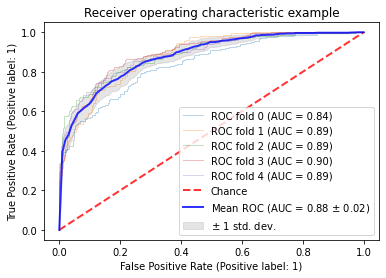

In [43]:
cv = StratifiedKFold(n_splits=5,random_state = 231,shuffle=True)
#classifier = svm.SVC( random_state=5)
#classifier = LogisticRegression(random_state=5)
#classifier = LogisticRegressionCV(random_state=5)
classifier = RandomForestClassifier(max_depth=20,n_estimators = 500, random_state=0,n_jobs=6)
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

fig, ax = plt.subplots()
for i, (train, test) in enumerate(cv.split(X2, y2)):
    classifier.fit(X2[train], y2[train])
    viz = RocCurveDisplay.from_estimator(
        classifier,
        X2[test],
        y2[test],
        name="ROC fold {}".format(i),
        alpha=0.3,
        lw=1,
        ax=ax,
    )
    interp_tpr = np.interp(mean_fpr, viz.fpr, viz.tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    aucs.append(viz.roc_auc)

ax.plot([0, 1], [0, 1], linestyle="--", lw=2, color="r", label="Chance", alpha=0.8)

mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)
ax.plot(
    mean_fpr,
    mean_tpr,
    color="b",
    label=r"Mean ROC (AUC = %0.2f $\pm$ %0.2f)" % (mean_auc, std_auc),
    lw=2,
    alpha=0.8,
)

std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
ax.fill_between(
    mean_fpr,
    tprs_lower,
    tprs_upper,
    color="grey",
    alpha=0.2,
    label=r"$\pm$ 1 std. dev.",
)

ax.set(
    xlim=[-0.05, 1.05],
    ylim=[-0.05, 1.05],
    title="Receiver operating characteristic example",
)
ax.legend(loc="lower right")
plt.show()

In [44]:
from sklearn.metrics import PrecisionRecallDisplay

#display = PrecisionRecallDisplay.from_estimator(
#    classifier, X_test, y_test, name="LinearSVC"
#)
#_ = display.ax_.set_title("2-class Precision-Recall curve")

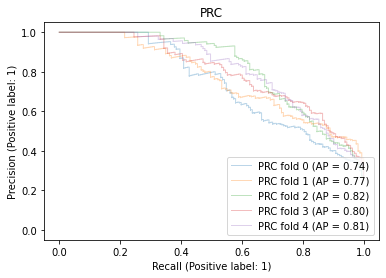

In [45]:
cv = StratifiedKFold(n_splits=5,random_state = 231,shuffle=True)
#classifier = svm.SVC( random_state=5)
#classifier = LogisticRegression(random_state=5)
#classifier = LogisticRegressionCV(random_state=5)
classifier = RandomForestClassifier(max_depth=20,n_estimators = 500, random_state=0,n_jobs=6)
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

fig, ax = plt.subplots()
for i, (train, test) in enumerate(cv.split(X2, y2)):
    classifier.fit(X2[train], y2[train])
    viz = PrecisionRecallDisplay.from_estimator(
        classifier,
        X2[test],
        y2[test],
        name="PRC fold {}".format(i),
        alpha=0.3,
        lw=1,
        ax=ax,
    )
    #interp_tpr = np.interp(mean_fpr, viz.fpr, viz.tpr)
    #interp_tpr[0] = 0.0
    #tprs.append(interp_tpr)
    #aucs.append(viz.roc_auc)



ax.set(
    xlim=[-0.05, 1.05],
    ylim=[-0.05, 1.05],
    title="PRC",
)
ax.legend(loc="lower right")
plt.show()

In [46]:
np.mean([0.74,0.77,0.82,0.80,0.81])

0.788

In [47]:
np.std([0.74,0.77,0.82,0.80,0.81])

0.029257477676655586

# Do data imputation

In [48]:
import numpy as np
import pickle
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

In [49]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import svm, datasets
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import auc
from sklearn.metrics import RocCurveDisplay
from sklearn.model_selection import StratifiedKFold
import numpy as np
from sklearn.metrics import roc_auc_score
from sklearn.metrics import PrecisionRecallDisplay

In [50]:
web_features_use2 = []
bib_features_use2 = []
tag_features_use2 = []
label2 = []

In [51]:
web_features1 = []
web_features0 = []
tmp = []

for batch in range(0,100):
    with open('labeled_journal_feature_2024\\web_content_features_1_'+str(batch)+'.pkl', 'rb') as f:
        web_features1 += pickle.load(f)
        

    with open('labeled_journal_feature_2024\\web_content_features_0_'+str(batch)+'.pkl', 'rb') as f:
        web_features0 += pickle.load(f)

In [52]:
tag_features1 = []
tag_features0 = []

for batch in range(100):
    with open('labeled_journal_feature_2024\\web_tag_features_1_'+str(batch)+'.pkl', 'rb') as f:
        tag_features1 += pickle.load(f)

    with open('labeled_journal_feature_2024\\web_tag_features_0_'+str(batch)+'.pkl', 'rb') as f:
        tag_features0 += pickle.load(f)

In [53]:
labeled_journals = pd.read_csv('doaj_journal_list_urls_from_doaj_bing_v1.csv')

In [54]:
labeled_journals['ISSN'] = labeled_journals['ISSN'].apply(str.strip)

In [55]:
labeled_journals.shape

(15395, 11)

In [56]:
bibilometrics_after_average = pd.read_csv('doaj_bibilometrics_after_average.csv')

In [57]:
bib_features0 = []
bib_features_ind0 = []
counter = 0
for ind,row in labeled_journals[labeled_journals['Reason'] == 'Still in DOAJ index'].iterrows():
    if row['Journal_Title_Normalized'] in (bibilometrics_after_average['NormalizedName'].tolist()):
        tmp = bibilometrics_after_average.index[bibilometrics_after_average['NormalizedName']==row['Journal_Title_Normalized']]

        val = bibilometrics_after_average.iloc[tmp].drop(columns=['NormalizedName','Reason']).values.tolist()[0]
        #print(val)
        #print(len(val))
        bib_features0.append(val)
        bib_features_ind0.append(counter)
    else:
        bib_features0.append([-1]*18)
    counter += 1

In [58]:
bib_features1 = []
bib_features_ind1 = []
counter = 0
for ind,row in labeled_journals[labeled_journals['Reason'] != 'Still in DOAJ index'].iterrows():
    if row['Journal_Title_Normalized'] in (bibilometrics_after_average['NormalizedName'].tolist()):
        tmp = bibilometrics_after_average.index[bibilometrics_after_average['NormalizedName']==row['Journal_Title_Normalized']]
        #print(tmp)
        val = bibilometrics_after_average.iloc[tmp].drop(columns=['NormalizedName','Reason']).values.tolist()[0]
        #print(val)
        #print(len(val))
        bib_features1.append(val)
        bib_features_ind1.append(counter)
    else:
        bib_features1.append([-1]*18)
    counter += 1

In [59]:
len(web_features0)

12859

In [60]:
len(web_features0)+len(bib_features1)

15395

In [61]:
for ind,v in enumerate(zip(web_features0,bib_features0,tag_features0)):
    w = v[0]
    b = v[1]
    t = v[2]
    
    if len(b) == 18:
        bib_features_use2.append(b)
    else:
        bib_features_use2.append([-1]*18)
    if len(w) > 9:
        web_features_use2.append(w)
    else:
        web_features_use2.append([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 19473, -1, -1, -1, -1, -1,-1])
    
    if len(t) > 1:
        tag_features_use2.append(t)
    else:
        tag_features_use2.append('empty html tag')
        
        
    label2.append(0)

In [62]:
len(label2)

12859

In [63]:
for ind,v in enumerate(zip(web_features1,bib_features1,tag_features1)):
    w = v[0]
    b = v[1]
    t = v[2]

    if len(b) == 18:
        bib_features_use2.append(b)
    else:
        bib_features_use2.append([-1]*18)
    if len(w) > 9:
        web_features_use2.append(w)
    else:
        web_features_use2.append([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 19473, -1, -1, -1, -1, -1,-1])
    if len(t) > 1:
        tag_features_use2.append(t)
    else:
        tag_features_use2.append('empty html tag')
        
        
    label2.append(1)

In [64]:
len(label2)

15395

In [65]:
vectorizer = TfidfVectorizer()

In [66]:
tag_x2 = vectorizer.fit_transform(tag_features_use2).todense()

In [153]:
#pickle.dump(vectorizer, open('tag_tfidf_curr', 'wb'))

In [67]:
X2 = []

In [68]:
len(tag_x2[0].tolist()[0])

640

In [69]:
len(w),len(bib_features_use2[ind])

(8, 18)

In [70]:
for ind,w in enumerate(web_features_use2):
    tmp = w+bib_features_use2[ind]+tag_x2[ind].tolist()[0]
    #print(len(tmp))
    #print(len(bib_features_use2[ind]))
    X2.append(tmp)

In [71]:
[xx[0:16] for xx in X2]

[[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 19473, -1, -1, -1, -1, -1],
 [-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 10259.5, 31, -1, -1, 1, 1],
 [-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 19473, -1, -1, -1, -1, -1],
 [-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 19473, -1, -1, -1, -1, -1],
 [-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 19473, -1, -1, -1, -1, -1],
 [-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 19473, -1, -1, -1, -1, -1],
 [-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 19473, -1, -1, -1, -1, -1],
 [-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 19473, -1, -1, -1, -1, -1],
 [-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 19473, -1, -1, -1, -1, -1],
 [-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 19473, -1, -1, -1, -1, -1],
 [-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 7070.0, 30, -1, -1, 1, 1],
 [-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 19473, 2, 1, 1, 1, 1],
 [-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 19473, -1, -1, -1, -1, -1],
 [-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 19473, -1, -1, -1, -1, -1],
 [-1, -1, -1, -1, -1, -1, 

In [72]:
len(X2[0])

675

In [73]:
len(X2)

15395

In [74]:
X3 = np.array(X2)
y3 = np.array(label2)

In [75]:
len(web_features_use2)

15395

In [76]:
len(X2)

15395

In [77]:
X3[0]

array([-1.00000000e+00, -1.00000000e+00, -1.00000000e+00, -1.00000000e+00,
       -1.00000000e+00, -1.00000000e+00, -1.00000000e+00, -1.00000000e+00,
       -1.00000000e+00, -1.00000000e+00,  1.94730000e+04, -1.00000000e+00,
       -1.00000000e+00, -1.00000000e+00, -1.00000000e+00, -1.00000000e+00,
       -1.00000000e+00,  2.01200000e+03,  2.33333333e-01,  3.60000000e+02,
        5.72222222e-01,  2.77777778e-03,  5.00000000e-02,  2.77777778e-03,
        1.63055556e+00,  1.97222222e-01,  5.55555556e-03,  8.19444444e-01,
        1.11197917e+00,  1.75903614e+00,  3.01323024e+00,  5.55555556e-01,
        1.30555556e-01,  1.97222222e-01,  1.72222222e-01,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  

In [78]:
np.mean(y3)

0.16472880805456316

In [79]:
classifier = RandomForestClassifier(max_depth=20,n_estimators = 500, random_state=0,n_jobs=6)

In [80]:
classifier.fit(X3,y3)

RandomForestClassifier(max_depth=20, n_estimators=500, n_jobs=6, random_state=0)

In [168]:
#pickle.dump(classifier, open('all_features_imputed_randomforest', 'wb'))

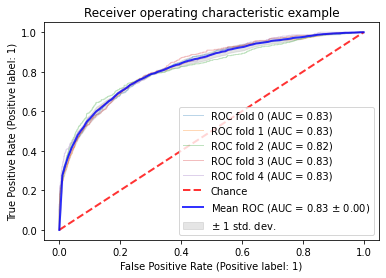

In [81]:
cv = StratifiedKFold(n_splits=5,random_state = 231,shuffle=True)
#classifier = svm.SVC( random_state=5)
#classifier = LogisticRegression(random_state=5)
#classifier = LogisticRegressionCV(random_state=5)
classifier = RandomForestClassifier(max_depth=20,n_estimators = 500, random_state=0,n_jobs=6)
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

fig, ax = plt.subplots()
for i, (train, test) in enumerate(cv.split(X3, y3)):
  
    classifier.fit(X3[train], y3[train])
    viz = RocCurveDisplay.from_estimator(
        classifier,
        X3[test],
        y3[test],
        name="ROC fold {}".format(i),
        alpha=0.3,
        lw=1,
        ax=ax,
    )
    interp_tpr = np.interp(mean_fpr, viz.fpr, viz.tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    aucs.append(viz.roc_auc)

ax.plot([0, 1], [0, 1], linestyle="--", lw=2, color="r", label="Chance", alpha=0.8)

mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)
ax.plot(
    mean_fpr,
    mean_tpr,
    color="b",
    label=r"Mean ROC (AUC = %0.2f $\pm$ %0.2f)" % (mean_auc, std_auc),
    lw=2,
    alpha=0.8,
)

std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
ax.fill_between(
    mean_fpr,
    tprs_lower,
    tprs_upper,
    color="grey",
    alpha=0.2,
    label=r"$\pm$ 1 std. dev.",
)

ax.set(
    xlim=[-0.05, 1.05],
    ylim=[-0.05, 1.05],
    title="Receiver operating characteristic example",
)
ax.legend(loc="lower right")
plt.show()

In [82]:
set(y3)

{0, 1}

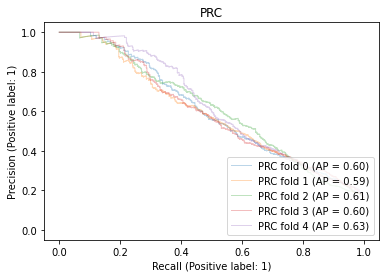

In [83]:
cv = StratifiedKFold(n_splits=5,random_state = 231,shuffle=True)
#classifier = svm.SVC( random_state=5)
#classifier = LogisticRegression(random_state=5)
#classifier = LogisticRegressionCV(random_state=5)
classifier = RandomForestClassifier(max_depth=20,n_estimators = 500, random_state=0,n_jobs=6)
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

fig, ax = plt.subplots()
for i, (train, test) in enumerate(cv.split(X3, y3)):
    classifier.fit(X3[train], y3[train])
    viz = PrecisionRecallDisplay.from_estimator(
        classifier,
        X3[test],
        y3[test],
        name="PRC fold {}".format(i),
        alpha=0.3,
        lw=1,
        ax=ax,
    )
    #interp_tpr = np.interp(mean_fpr, viz.fpr, viz.tpr)
    #interp_tpr[0] = 0.0
    #tprs.append(interp_tpr)
    #aucs.append(viz.roc_auc)



ax.set(
    xlim=[-0.05, 1.05],
    ylim=[-0.05, 1.05],
    title="PRC",
)
ax.legend(loc="lower right")
plt.show()

In [84]:
np.mean([0.60,0.59,0.61,0.60,0.63])

0.606

In [85]:
np.std([0.60,0.59,0.61,0.60,0.63])

0.013564659966250548

In [212]:
from sklearn.feature_selection import RFECV

In [213]:
X4 = np.array(X2)[:,:36]
y4 = np.array(label2)

In [214]:
estimator = RandomForestClassifier(max_depth=3,n_estimators = 500, random_state=0,n_jobs=6)

In [215]:
selector = RFECV(estimator, step=1, cv=5,min_features_to_select=5)

In [216]:
selector = selector.fit(X4, y4)

In [217]:
selector.support_

array([False, False, False, False, False, False, False, False, False,
       False, False,  True, False, False, False, False, False,  True,
       False, False, False, False, False, False, False, False,  True,
       False,  True, False, False,  True, False, False, False, False])

In [218]:
len(selector.support_[12:])

24

In [219]:
bibilometrics_after_average.columns,[selector.support_[12:]]

(Index(['Reason', 'NormalizedName', 'journal_year_first_publish',
        'total_num_journal_cited', 'num_journal_publication',
        'total_num_journal_reference', 'journal_num_journal_self_cited',
        'journal_journal_cited_num', 'journal_num_journal_self_reference',
        'journal_avg_last_author_hindex', 'num_journal_author',
        'journal_num_author_self_reference', 'journal_num_author_referenced',
        'journal_avg_middle_author_hindex', 'journal_avg_first_author_hindex',
        'journal_avg_hindex', 'journal_num_author_cited',
        'journal_num_affiliation_cited', 'num_journal_affiliation',
        'journal_num_affiliation_referenced'],
       dtype='object'),
 [array([False, False, False, False, False,  True, False, False, False,
         False, False, False, False, False,  True, False,  True, False,
         False,  True, False, False, False, False])])

# Stack Model with model imputation

In [86]:
from sklearn.model_selection import train_test_split

In [87]:
web_features1 = []
web_features0 = []
content_x = []
content_found = []
label = []
for batch in range(0,100):
    with open('labeled_journal_feature_2024\\web_content_features_0_'+str(batch)+'.pkl', 'rb') as f:
        web_features0 += pickle.load(f)

label += [1] * len(web_features0)
counter = 0
for ind,wf in enumerate(web_features0):
    if len(wf) <9:
        content_x.append([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 19473, -1, -1, -1, -1, -1,-1,counter,0])
    else:
        content_x.append([wf,counter,0])
        content_found.append(counter)
    counter += 1

        
for batch in range(0,100):
    with open('labeled_journal_feature_2024\\web_content_features_1_'+str(batch)+'.pkl', 'rb') as f:
        web_features1 += pickle.load(f)
        
label += [0] * len(web_features1)
for ind,wf in enumerate(web_features1):
    if len(wf) <9:
        content_x.append([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 19473, -1, -1, -1, -1, -1,-1,counter,1])
    else:
        content_x.append([wf,counter,1])
        content_found.append(counter)
    counter += 1


In [88]:
len(content_x),len(label)

(15395, 15395)

In [89]:
tag_features1 = []
tag_features0 = []
tag_x = []
tag_found = []
labels = []

counter = 0

for batch in range(100):
    with open('labeled_journal_feature_2024\\web_tag_features_0_'+str(batch)+'.pkl', 'rb') as f:
        tag_features0 += pickle.load(f)
        
for ind,wf in enumerate(tag_features0):
    if len(wf) <1:
        tag_x.append(['empty html tag',0])
    else:
        tag_x.append([wf])
        tag_found.append(counter)
        
    tag_x[-1].append(counter)
    tag_x[-1].append(0)
    counter += 1
    
labels += [0] * len(tag_features0)

for batch in range(100):
    with open('labeled_journal_feature_2024\\web_tag_features_1_'+str(batch)+'.pkl', 'rb') as f:
        tag_features1 += pickle.load(f)


for ind,wf in enumerate(tag_features1):
    if len(wf) <1:
        tag_x.append(['empty html tag',1])
    else:
        tag_x.append([wf])
        tag_found.append(counter)
        
    tag_x[-1].append(counter)
    tag_x[-1].append(1)
    counter += 1
        


labels += [1] * len(tag_features1)    

In [90]:
labels.index(1)

12859

In [91]:
labeled_journals = pd.read_csv('doaj_journal_list_urls_from_doaj_bing_v1.csv')

In [92]:
labeled_journals

,Unnamed: 0,Journal_Title_Normalized,added,Journal Title,ISSN,Remove_Date,Add_Date,Reason,Data Source,URL,reason_category
0,0,"#tear: revista de educação, ciência e tecnologia",True,"#Tear: Revista de Educação, Ciência e Tecnologia",2238-8079,1677-09-22,2015-07-20,Still in DOAJ index,DOAJ,https://periodicos.ifrs.edu.br/index.php/tear/...,interesting reason
1,1,(en)clave comahue,True,(En)clave Comahue,2545-6466,1677-09-22,2019-05-13,Still in DOAJ index,DOAJ,http://revele.uncoma.edu.ar/htdoc/revele/index...,interesting reason
2,2,(پژوهش حسابداری و حسابرسی (پیوسته,True,(پژوهش حسابداری و حسابرسی (پیوسته,2676-7554,1677-09-22,2020-05-25,Still in DOAJ index,DOAJ,https://ijar.alzahra.ac.ir/,interesting reason
3,3,100-cs,True,100-Cs,0719-5737,1677-09-22,2018-12-27,Still in DOAJ index,DOAJ,http://100cs.cl/,interesting reason
4,4,1616,True,1616,0210-7287,1677-09-22,2020-03-09,Still in DOAJ index,DOAJ,http://revistas.usal.es/index.php/1616_Anuario...,interesting reason
...,...,...,...,...,...,...,...,...,...,...,...
15390,15405,силовое и энергетическое оборудование: автоном...,False,Силовое и энергетическое оборудование: Автоном...,2618-8716,2020-11-19,1677-09-22,Website URLs have security issues,DOAJ,https://onlinebooks.library.upenn.edu/webbin/b...,interesting reason
15391,15406,українська біографістика,False,Українська біографістика,2520-2855,2021-02-11,1677-09-22,Journal not adhering to best practice,DOAJ,http://ub.nbuv.gov.ua/,interesting reason
15392,15407,экономика региона,False,Экономика региона,2072-6414,2021-03-01,1677-09-22,Journal not adhering to Best practice,DOAJ,https://economyofregion.ru/,interesting reason
15393,15408,اندیشه‌های نوین تربیتی,False,اندیشه‌های نوین تربیتی,2476-7654,2022-06-09,1677-09-22,Journal not adhering to Best practice,DOAJ,http://ensani.ir/fa/article/journal/65/%D8%A7%...,interesting reason


In [93]:
bibilometrics_after_average = pd.read_csv('doaj_bibilometrics_after_average.csv')

In [94]:
bib_features = []
bib_features_found = []
counter = 0
labels = [] 
for ind,row in labeled_journals.iterrows():
    
    if row['Reason'] == 'Still in DOAJ index':
        label = 0
    else:
        label = 1
    
    if row['Journal_Title_Normalized'] in (bibilometrics_after_average['NormalizedName'].tolist()):
        tmp = bibilometrics_after_average.index[bibilometrics_after_average['NormalizedName']==row['Journal_Title_Normalized']]
        #print(tmp)
        val = bibilometrics_after_average.iloc[tmp].drop(columns=['NormalizedName','Reason']).values.tolist()[0]
        #print(val)
        #print(len(val))
        bib_features.append(val+[ind]+[label])
        bib_features_found.append(ind)
    else:
        bib_features.append([-1]*18+[ind]+[label])
    
    labels.append(label)
    
    counter += 1

In [95]:
bib_features[:10]

[[2012.0,
  0.2333333333333333,
  360.0,
  0.5722222222222222,
  0.0027777777777777,
  0.05,
  0.0027777777777777,
  1.6305555555555555,
  0.1972222222222222,
  0.0055555555555555,
  0.8194444444444444,
  1.1119791666666667,
  1.7590361445783131,
  3.013230240549828,
  0.5555555555555556,
  0.1305555555555555,
  0.1972222222222222,
  0.1722222222222222,
  0,
  0],
 [-1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  1,
  0],
 [-1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  2,
  0],
 [-1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  3,
  0],
 [-1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  4,
  0],
 [-1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  5,
  0],
 [-1,
  -1,
  -1,
  -1,
  -1,
  -1,
  

In [96]:
labels.index(1)

12859

In [97]:
len(content_x),len(tag_x),len(bib_features)

(15395, 15395, 15395)

In [98]:
all_x = []
for ind,xx in enumerate(content_x):
    vec = [xx,tag_x[ind],bib_features[ind]]
    
    if xx[-1] != bib_features[ind][-1] or xx[-1] != tag_x[ind][-1]:
        print(xx[-1],bib_features[ind][-1])
        print(ind)
        break
    all_x.append(vec)

In [99]:
# 5 fold
stack_train0, stack_test, stack_y0, stack_ytest =  train_test_split(all_x, labels, test_size = 0.2,random_state=6)
stack_train1, stack_test1, stack_y1, stack_ytest1 =  train_test_split(stack_train0, stack_y0, test_size = 0.2,random_state=6)

In [100]:
stack_y1

[0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,


In [101]:
content_train0 = [] 
content_y0 = []
for ind,vec in enumerate(stack_train1):
    xx = vec[0]
    if xx[-2] in content_found:
        content_train0.append(xx[:-2][0])
        content_y0.append(xx[-1])
content_classifier = RandomForestClassifier(max_depth=20,n_estimators = 500, random_state=0,n_jobs=6).fit(content_train0,content_y0)

In [102]:
content_train1 = [] 
content_y1 = []
for ind,vec in enumerate(stack_test1):
    xx = vec[0]
    if xx[-2] in content_found:
        content_train1.append(xx[:-2][0])
        content_y1.append(xx[-1])

In [103]:
content_test = [] 
content_ytest = []
for ind,vec in enumerate(stack_test):
    xx = vec[0]
    if xx[-2] in content_found:
        content_test.append(xx[:-2][0])
    content_ytest.append(xx[-1])

In [104]:
content_input_x = content_classifier.predict_proba(content_train1)[:,1]

In [105]:
content_input_x2 = content_classifier.predict_proba(content_test)[:,1]

In [106]:
content_input_x

array([0.622     , 0.36237328, 0.33155124, ..., 0.31002738, 0.20038829,
       0.07520634])

In [107]:
np.mean(content_input_x2)

0.19120115825721212

In [108]:
len(content_input_x),len(content_input_x2)

(1656, 2147)

In [109]:
content_input_xx = []
counter = 0
for ind,vec in enumerate(stack_test1):
    xx = vec[0]
    if xx[-2] in content_found:
        content_input_xx.append(content_input_x[counter])
        counter += 1
    else:
        content_input_xx.append(-1)

In [110]:
content_input_xx

[0.622,
 -1,
 -1,
 -1,
 0.36237327983799317,
 0.3315512376445734,
 0.5641810631775231,
 0.3536269693957274,
 0.4231792656747664,
 -1,
 0.14368515605301962,
 -1,
 0.3536269693957274,
 0.12071933386138442,
 -1,
 0.04995706711908796,
 0.3714310915485938,
 0.07520634051468914,
 0.03534496133025761,
 0.3536269693957274,
 0.20852295845039714,
 0.1157935611628449,
 0.09674082179700144,
 -1,
 0.6633279834843258,
 0.07520634051468914,
 -1,
 0.3536269693957274,
 -1,
 0.02486560200432684,
 0.07520634051468914,
 0.002324504329318756,
 -1,
 -1,
 0.01633212929601567,
 0.065,
 0.09204761904761904,
 -1,
 -1,
 0.3536269693957274,
 -1,
 -1,
 -1,
 -1,
 -1,
 0.31067350781516484,
 0.14992006837235286,
 -1,
 0.026762039386041093,
 0.3536269693957274,
 -1,
 -1,
 0.13359875285704575,
 0.3536269693957274,
 -1,
 -1,
 0.2007004122278672,
 0.05965535763713089,
 0.3536269693957274,
 -1,
 0.09244378596295236,
 0.1245,
 0.012,
 -1,
 0.1683766613774065,
 -1,
 -1,
 0.18455262233311792,
 0.07520634051468914,
 0.0080261

In [111]:
content_input_xx2 = []
counter = 0
content_y_test = []
for ind,vec in enumerate(stack_test):
    xx = vec[0]
    if xx[-2] in content_found:
        content_input_xx2.append(content_input_x2[counter])
        counter += 1
    else:
        content_input_xx2.append(-1)
    
    content_y_test.append(stack_ytest[ind])

In [112]:
from sklearn.metrics import average_precision_score

In [113]:
average_precision_score(content_y0, content_classifier.predict_proba(content_train0)[:,1])

0.7451780526070639

In [114]:
average_precision_score(content_y1, content_classifier.predict_proba(content_train1)[:,1])

0.38931043093144707

In [115]:
len(tag_x)

15395

In [116]:
tag_train0 = [] 
tag_y0 = []
for ind,vec in enumerate(stack_train1):
    xx = vec[1]
    if ind in tag_found:
        tag_train0.append(xx[0])
        tag_y0.append(xx[-1])

In [117]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [118]:
vectorizer = TfidfVectorizer()

In [119]:
tag_train0 = vectorizer.fit_transform(tag_train0)

In [120]:
tag_classifier = RandomForestClassifier(max_depth=20,n_estimators = 500, random_state=0,n_jobs=6).fit(tag_train0,tag_y0)

In [121]:
tag_train1 = [] 
tag_y1 = []
for ind,vec in enumerate(stack_test1):
    xx = vec[1]
    if ind in tag_found:
        tag_train1.append(xx[0])
        tag_y1.append(xx[-1])

In [122]:
tag_train1[0]

'html head meta title meta meta meta meta meta meta meta meta meta meta meta meta meta link link link link link link link link link link link link link link link link link link link link link link link link link link script script script script script script script script script script script script script script script script script script script meta link meta script style style style style style style meta meta meta script script style script script body div script noscript iframe div div div div div header div div div div div div div div div div div a img div div div a img div div div div div div div div div div div div div div div div div div span a span a div div div a span span div div div div div div div div div div nav ol li a li a li a li a li a script section div div div div div div div div div div div a span div div div div div div div div div div div div div button span span i div span i ul li li a li a i li li a i div button span span i div span i ul li li a li a li a li 

In [123]:
tag_test = [] 
tag_ytest = []
for ind,vec in enumerate(stack_test):
    xx = vec[1]
    if xx[-2] in tag_found:
        tag_test.append(xx[0])
    tag_ytest.append(xx[-1])

In [124]:
xx

['html head meta meta title meta meta link link link link link link link body div a a a div header div div h1 a img nav div ul li a li a li a li a li a li a form input input button div a a span nav ul li a li a div div div div h2 div div div a img div span span div div h2 ul li div div a div div div ul li a li div div a div div div ul li a li div div a div div div ul li a li div div a div div div ul li a li div div a div div div ul li a li div div a div div div ul li a li div div a div div div ul li a a div table tbody tr td p a img td td a img td td p a img td td img tr td td td td td td td tr td a img td td a img td td a img td td a img p div div div p strong p a span span p a p a p a p a p strong p a p a p a p a div div p a a img div div p a img div div p img div div p a img div span div ul li a li a div span div ul li a li a li a div div div a img script script script script script script script',
 5940,
 0]

In [125]:
tag_train1 = vectorizer.transform(tag_train1)

In [126]:
tag_input_x = tag_classifier.predict_proba(tag_train1)[:,1]

In [127]:
tag_test = vectorizer.transform(tag_test)

In [128]:
tag_input_x2 = tag_classifier.predict_proba(tag_test)[:,1]

In [129]:
tag_input_xx = []
counter = 0
for ind,vec in enumerate(stack_test1):
    xx = vec[1]
    if ind in tag_found:
        tag_input_xx.append(tag_input_x[counter])
        counter += 1
    else:
        tag_input_xx.append(-1)

In [130]:
tag_input_xx

[0.19058256331138254,
 0.1445452991856705,
 0.23549789087006698,
 0.2574102655446877,
 0.23594025037754246,
 0.08025218157637443,
 0.17141834235819056,
 0.16907735066008472,
 0.10641306720567219,
 0.15529417575557383,
 0.17730129209580248,
 0.08671014970324653,
 0.09248031657927154,
 0.21898417197040357,
 0.09905083257063849,
 0.283249182034262,
 0.09774448373752859,
 0.014148117731926792,
 0.05841412252908056,
 0.29974241054137013,
 0.04672761743424717,
 0.11249769238261825,
 0.07681743694514938,
 0.059410216226239675,
 0.39615960217942453,
 0.061771622918721764,
 0.0483796955768852,
 0.3028701206458467,
 0.10656379582770359,
 0.0576380779105644,
 0.12599595326414975,
 0.10744930507459366,
 0.04239256852513531,
 0.14860434658033447,
 0.07673313774667437,
 0.10630804456848038,
 0.11997613892288737,
 0.11767178058244274,
 0.13205256200769883,
 0.2360072762445419,
 0.16201935199868867,
 0.0901221855909853,
 0.061561331775852976,
 0.10719570824834382,
 0.2792803151904327,
 0.0581771234181

In [131]:
tag_input_xx2 = []
counter = 0
tag_y_test = []
for ind,vec in enumerate(stack_test):
    xx = vec[1]
    if xx[-2] in tag_found:
        tag_input_xx2.append(tag_input_x2[counter])
        counter += 1
    else:
        tag_input_xx2.append(-1)
        
    tag_y_test.append(stack_ytest[ind])

In [132]:
tag_input_xx2

[0.1181726724565082,
 0.06585184469013067,
 0.07672531283577527,
 0.07201195020716179,
 -1,
 0.0718504448109541,
 0.20208871836020098,
 0.07692741709353972,
 0.2758408087086948,
 0.06585059862319677,
 0.15323722495300443,
 0.021853921202156186,
 0.09241345315269478,
 0.12190819814289412,
 0.05898650527531958,
 0.14639104256860655,
 0.11367460069097572,
 0.0866805239935667,
 0.09097483737175992,
 0.04970935449712031,
 0.07669263071243654,
 0.2649783363148378,
 0.10069712447246264,
 0.14093469316265594,
 0.17979787267533456,
 0.27689603052602946,
 0.12326154116761186,
 0.1038559464215293,
 0.044515062548743344,
 0.10561053600266455,
 0.13869004403533122,
 0.23519743048415676,
 0.36562514091790693,
 0.08148090194791215,
 0.0654883404225325,
 0.4246697023132102,
 0.021137169439789615,
 0.04909388586133461,
 0.18390058422790867,
 0.06046102073874637,
 0.0654883404225325,
 0.14322588615041568,
 0.17640886155718866,
 0.12186041276003738,
 0.0654883404225325,
 0.2714861522997534,
 0.0653906735

In [133]:
average_precision_score(tag_y0, tag_classifier.predict_proba(tag_train0)[:,1])

0.9566683607397612

In [134]:
average_precision_score(tag_y1, tag_classifier.predict_proba(tag_train1)[:,1])

0.576287704995259

In [135]:
len(bib_features)

15395

In [136]:
bib_train0 = [] 
bib_y0 = []
for ind,vec in enumerate(stack_train1):
    xx = vec[2]
    if xx[-2] in bib_features_found:
        bib_train0.append(xx[:-2])
        bib_y0.append(xx[-1])

In [137]:
xx

[1987.0,
 24.074257425742573,
 606.0,
 33.06270627062706,
 0.3234323432343234,
 1.056105610561056,
 0.3234323432343234,
 4.712871287128713,
 2.514851485148515,
 0.6386138613861386,
 39.31683168316832,
 5.429560332420259,
 4.965517241379311,
 5.863244905679118,
 37.56930693069307,
 2.834983498349835,
 2.514851485148515,
 2.2508250825082508,
 3706,
 0]

In [138]:
bib_train0

[[2013.0,
  0.7044652447445143,
  6517.0,
  1.6042657664569586,
  0.0019947828755562,
  0.2539512045419672,
  0.0016878932023937,
  1.579100813257634,
  0.432560994322541,
  0.0061377934632499,
  6.34525088230781,
  1.5218042447356737,
  4.09368530020704,
  4.315906228118025,
  2.910695105109713,
  0.316710142703698,
  0.432560994322541,
  0.356759245051404],
 [2003.0,
  0.3235294117647059,
  340.0,
  7.070588235294117,
  0.0617647058823529,
  0.0852941176470588,
  0.0588235294117647,
  1.3352941176470587,
  1.3,
  0.038235294117647,
  18.355882352941176,
  0.5624631268436578,
  3.645161290322581,
  3.9985754985754975,
  0.9352941176470588,
  0.0911764705882352,
  1.3,
  2.1029411764705883],
 [2009.0,
  3.614107883817427,
  241.0,
  12.473029045643154,
  0.1493775933609958,
  1.5020746887966805,
  0.0663900414937759,
  3.908713692946058,
  0.8423236514522822,
  0.2282157676348547,
  16.46887966804979,
  4.380208333333333,
  6.094936708860759,
  6.071568627450979,
  6.074688796680498,
 

In [139]:
bib_y0

[1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,


In [140]:
bib_classifier = RandomForestClassifier(max_depth=20,n_estimators = 500, random_state=0,n_jobs=6).fit(bib_train0,bib_y0)

In [141]:
bib_train1 = [] 
bib_y1 = []
for ind,vec in enumerate(stack_test1):
    xx = vec[2]
    if xx[-2] in bib_features_found:
        bib_train1.append(xx[:-2])
        bib_y1.append(xx[-1])

In [142]:
bib_train1

[[2007.0,
  0.5487364620938628,
  277.0,
  2.812274368231047,
  0.0108303249097472,
  0.1696750902527075,
  0.0108303249097472,
  1.523465703971119,
  0.2671480144404332,
  0.0324909747292418,
  5.317689530685921,
  1.7558641975308644,
  2.8412698412698414,
  3.162882882882883,
  1.447653429602888,
  0.2996389891696751,
  0.2671480144404332,
  1.0577617328519855],
 [2009.0,
  13.63344407530454,
  903.0,
  16.303433001107418,
  0.1461794019933555,
  4.217054263565892,
  0.1284606866002214,
  5.259136212624584,
  2.4274640088593578,
  0.1882613510520487,
  62.93244739756368,
  3.177632273146077,
  4.41259842519685,
  5.377336110300715,
  61.310077519379846,
  4.143964562569214,
  2.4274640088593578,
  2.988925802879291],
 [2010.0,
  18.27258193445244,
  1251.0,
  71.42446043165468,
  0.4324540367705835,
  1.1542765787370104,
  0.4148681055155875,
  15.860911270983214,
  3.46123101518785,
  0.8193445243804957,
  91.84972022382094,
  14.964021932110931,
  12.455855855855855,
  16.057626796

In [143]:
np.mean(bib_y1)

0.2512998266897747

In [144]:
bib_test = [] 
bib_ytest = []
for ind,vec in enumerate(stack_test):
    xx = vec[2]
    if xx[-2] in bib_features_found:
        bib_test.append(xx[:-2])
    bib_ytest.append(xx[-1])

In [145]:
bib_input_x = bib_classifier.predict_proba(bib_train1)[:,1]

In [146]:
average_precision_score(bib_y0, bib_classifier.predict_proba(bib_train0)[:,1])

0.9999999999999999

In [147]:
average_precision_score(bib_y1, bib_input_x)

0.6319254562701083

In [148]:
bib_input_xx = []
counter = 0

for ind,vec in enumerate(stack_test1):
    xx = vec[2]
    if ind in bib_features_found:
        bib_input_xx.append(bib_input_x[counter])
        counter += 1
    else:
        bib_input_xx.append(-1)
    
    

In [149]:
bib_input_xx

[0.18987218392490066,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 0.478,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 0.006,
 -1,
 -1,
 0.194,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 0.026,
 0.212,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 0.3589962128535625,
 -1,
 -1,
 -1,
 0.19076379007465966,
 -1,
 0.01,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 0.3386666666666666,
 -1,
 0.152,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 0.2527671169941718,
 -1,
 0.202,
 -1,
 -1,
 -1,
 -1,
 0.22858408866995075,
 -1,
 -1,
 0.26826923076923076,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 0.12492209866157834,
 -1,
 -1,
 -1,
 -1,
 0.36243139392432183,
 -1,
 -1,
 -1,
 -1,
 0.44281364052777733,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 0.4169166666666667,
 -1,
 -1,
 -1,
 0.09,
 -1,
 -1,
 -1,
 0.14244444444444446,
 -1,
 -1,
 -1,
 -1,
 -1,
 0.32614354066985646,
 -1,
 -1,
 -1,
 0.296,
 0.4481666666666667,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,

In [150]:
bib_input_x2 = bib_classifier.predict_proba(bib_test)[:,1]

In [151]:
bib_input_xx2 = []
counter = 0
bib_y_test = []
for ind,vec in enumerate(stack_test):
    xx = vec[2]
    if xx[-2] in bib_features_found:
        bib_input_xx2.append(bib_input_x2[counter])
        counter += 1
    else:
        bib_input_xx2.append(-1)
        
    bib_y_test.append(stack_ytest[ind])

In [152]:
bib_input_xx2

[-1,
 0.002,
 0.155,
 0.212,
 -1,
 0.024,
 -1,
 -1,
 -1,
 -1,
 -1,
 0.156,
 -1,
 -1,
 -1,
 0.066,
 0.19,
 -1,
 -1,
 0.414,
 -1,
 -1,
 -1,
 -1,
 -1,
 0.152,
 -1,
 -1,
 0.026,
 -1,
 0.002,
 0.6362352941176471,
 0.246625,
 -1,
 -1,
 0.828,
 0.298,
 0.158,
 -1,
 -1,
 -1,
 -1,
 -1,
 0.21623214285714287,
 -1,
 0.136,
 -1,
 -1,
 0.0775,
 0.034,
 0.24279135338345867,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 0.098,
 -1,
 -1,
 -1,
 0.876,
 -1,
 0.044,
 0.136,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 0.032,
 0.34428571428571425,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 0.508,
 -1,
 -1,
 -1,
 0.058,
 -1,
 -1,
 -1,
 -1,
 0.21,
 -1,
 -1,
 -1,
 -1,
 -1,
 0.2,
 0.124,
 -1,
 -1,
 -1,
 -1,
 0.182,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 0.052,
 -1,
 0.24,
 0.008,
 -1,
 0.4,
 -1,
 0.216,
 0.208,
 -1,
 -1,
 -1,
 0.19,
 -1,
 -1,
 -1,
 -1,
 0.6738571428571429,
 -1,
 0.2809802702338351,
 -1,
 -1,
 -1,
 -1,
 -1,
 0.3,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 0.17514151

In [153]:
len(content_input_xx),len(stack_test1)

(2464, 2464)

In [154]:
for zp in zip(content_y_test,tag_y_test,bib_y_test):

    if not (zp[0] == zp[1] and zp[1] == zp[2]):
        print('wrong')
   

In [155]:
len(content_y1),len(tag_y1),len(bib_y1)

(1656, 2460, 577)

In [156]:
XX = []
y = []
for ind,w in enumerate(stack_test1):
    vec = [content_input_xx[ind],tag_input_xx[ind],bib_input_xx[ind]]
    
    XX.append(vec)
    y.append(stack_y1[ind])

In [157]:
len(y)

2464

In [158]:
XX[0:500]

[[0.622, 0.19058256331138254, 0.18987218392490066],
 [-1, 0.1445452991856705, -1],
 [-1, 0.23549789087006698, -1],
 [-1, 0.2574102655446877, -1],
 [0.36237327983799317, 0.23594025037754246, -1],
 [0.3315512376445734, 0.08025218157637443, -1],
 [0.5641810631775231, 0.17141834235819056, -1],
 [0.3536269693957274, 0.16907735066008472, -1],
 [0.4231792656747664, 0.10641306720567219, -1],
 [-1, 0.15529417575557383, 0.478],
 [0.14368515605301962, 0.17730129209580248, -1],
 [-1, 0.08671014970324653, -1],
 [0.3536269693957274, 0.09248031657927154, -1],
 [0.12071933386138442, 0.21898417197040357, -1],
 [-1, 0.09905083257063849, -1],
 [0.04995706711908796, 0.283249182034262, -1],
 [0.3714310915485938, 0.09774448373752859, -1],
 [0.07520634051468914, 0.014148117731926792, -1],
 [0.03534496133025761, 0.05841412252908056, 0.006],
 [0.3536269693957274, 0.29974241054137013, -1],
 [0.20852295845039714, 0.04672761743424717, -1],
 [0.1157935611628449, 0.11249769238261825, 0.194],
 [0.09674082179700144, 

In [159]:
stack_classifier = RandomForestClassifier(max_depth=1,n_estimators = 5, random_state=0,n_jobs=6).fit(XX,y)

In [160]:
clf = LogisticRegression(random_state=0).fit(XX, y)

In [161]:
clf.score(XX,y)

0.8340097402597403

In [162]:
stack_classifier.score(XX,y)

0.8340097402597403

In [163]:
XX2 = []
y2 = []
for ind,w in enumerate(stack_test):
    vec = [content_input_xx2[ind],tag_input_xx2[ind],bib_input_xx2[ind]]
    
    XX2.append(vec)
    y2.append(stack_ytest[ind])

In [164]:
for zp in zip(y2,bib_y_test):
    if not (zp[0] == zp[1]):
        print(zp)
        print('wrong')
        break

In [165]:
len(content_y_test),len(y2)

(3079, 3079)

In [166]:
for zp in zip(content_y_test,y2):

    if not (zp[0] == zp[1]):
        print('wrong')

In [167]:
stack_classifier.score(XX2,y2)

0.8418317635595973

In [168]:
stack_classifier

RandomForestClassifier(max_depth=1, n_estimators=5, n_jobs=6, random_state=0)

In [169]:
average_precision_score(content_y_test, stack_classifier.predict_proba(XX2)[:,1])

0.15964300164296988

In [170]:
def check_three(vec):
    for x in vec:
        if x > 0.5:
            return x
        
    return np.max(vec)

In [171]:
average_precision_score(content_y_test, stack_classifier.predict_proba(XX2)[:,1])

0.15964300164296988

In [172]:
#simple use three predictions together
#0.5219902305925342
average_precision_score(content_y_test, [check_three (x) for x in XX2])

0.5076546850811261

In [173]:
average_precision_score(content_y_test, [x[0] for x in XX2])

0.29815155931421417

In [174]:
average_precision_score(content_y_test, [x[0] for x in XX2])

0.29815155931421417

In [175]:
average_precision_score(content_y_test, [x[1] for x in XX2])

0.5506204148636183

In [176]:
average_precision_score(content_y_test, [x[2] for x in XX2])

0.3393862334296834

In [177]:
average_precision_score(content_y_test, clf.predict_proba(XX2)[:,1])

0.5290491231704967

In [178]:
roc_auc_score(content_y_test, stack_classifier.predict_proba(XX2)[:,1])

0.44315038215833913

In [179]:
len(bib_features_found)

3728

In [180]:
for ind,w in enumerate(stack_test1):
    print(w[-1])

[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 15144, 1]
[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 846, 0]
[2007.0, 0.5487364620938628, 277.0, 2.812274368231047, 0.0108303249097472, 0.1696750902527075, 0.0108303249097472, 1.523465703971119, 0.2671480144404332, 0.0324909747292418, 5.317689530685921, 1.7558641975308644, 2.8412698412698414, 3.162882882882883, 1.447653429602888, 0.2996389891696751, 0.2671480144404332, 1.0577617328519855, 9668, 0]
[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 13162, 1]
[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 4314, 0]
[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 12994, 1]
[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 13854, 1]
[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 10054, 0]
[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 5865, 0]


[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 7080, 0]
[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 5621, 0]
[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 7017, 0]
[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 1346, 0]
[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 2307, 0]
[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 7146, 0]
[1998.0, 12.883180628272251, 3056.0, 32.5065445026178, 0.5297774869109948, 0.7889397905759162, 0.618782722513089, 8.724476439790577, 3.1541230366492146, 0.5955497382198953, 58.959096858638745, 6.4055500340759375, 4.892933618843683, 7.631726516666642, 31.01079842931937, 1.351439790575916, 3.1541230366492146, 1.7287303664921465, 4714, 0]
[2016.0, 0.4038461538461538, 104.0, 1.7692307692307692, 0.0, 0.173076923076923, 0.0, 0.6442307692307693, 0.125, 0.0096153846153846, 3.817307692307693, 1.2066666666666668,

In [181]:
len(stack_test1)

2464

# Stack Model with model imputation 5-fold cross validation

In [182]:
web_features1 = []
web_features0 = []
content_x = []
content_found = []
label = []
for batch in range(0,100):
    with open('labeled_journal_feature_2024\\web_content_features_0_'+str(batch)+'.pkl', 'rb') as f:
        web_features0 += pickle.load(f)

label += [1] * len(web_features0)
counter = 0
for ind,wf in enumerate(web_features0):
    if len(wf) <9:
        content_x.append([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 19473, -1, -1, -1, -1, -1,-1,counter,0])
    else:
        content_x.append([wf,counter,0])
        content_found.append(counter)
    counter += 1

        
for batch in range(0,100):
    with open('labeled_journal_feature_2024\\web_content_features_1_'+str(batch)+'.pkl', 'rb') as f:
        web_features1 += pickle.load(f)
        
label += [0] * len(web_features1)
for ind,wf in enumerate(web_features1):
    if len(wf) <9:
        content_x.append([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 19473, -1, -1, -1, -1, -1,-1,counter,1])
    else:
        content_x.append([wf,counter,1])
        content_found.append(counter)
    counter += 1

In [183]:
len(content_x),len(label)

(15395, 15395)

In [184]:
tag_features1 = []
tag_features0 = []
tag_x = []
tag_found = []
labels = []

counter = 0

for batch in range(100):
    with open('labeled_journal_feature_2024\\web_tag_features_0_'+str(batch)+'.pkl', 'rb') as f:
        tag_features0 += pickle.load(f)
        
for ind,wf in enumerate(tag_features0):
    if len(wf) <1:
        tag_x.append(['empty html tag',0])
    else:
        tag_x.append([wf])
        tag_found.append(counter)
        
    tag_x[-1].append(counter)
    tag_x[-1].append(0)
    counter += 1
    
labels += [0] * len(tag_features0)

for batch in range(100):
    with open('labeled_journal_feature_2024\\web_tag_features_1_'+str(batch)+'.pkl', 'rb') as f:
        tag_features1 += pickle.load(f)


for ind,wf in enumerate(tag_features1):
    if len(wf) <1:
        tag_x.append(['empty html tag',1])
    else:
        tag_x.append([wf])
        tag_found.append(counter)
        
    tag_x[-1].append(counter)
    tag_x[-1].append(1)
    counter += 1
        


labels += [1] * len(tag_features1)

In [185]:
labeled_journals = pd.read_csv('doaj_journal_list_urls_from_doaj_bing_v1.csv')

In [186]:
bibilometrics_after_average = pd.read_csv('doaj_bibilometrics_after_average.csv')

In [187]:
bib_features = []
bib_features_found = []
counter = 0
labels = [] 
for ind,row in labeled_journals.iterrows():
    
    if row['Reason'] == 'Still in DOAJ index':
        label = 0
    else:
        label = 1
    
    if row['Journal_Title_Normalized'] in (bibilometrics_after_average['NormalizedName'].tolist()):
        tmp = bibilometrics_after_average.index[bibilometrics_after_average['NormalizedName']==row['Journal_Title_Normalized']]
        #print(tmp)
        val = bibilometrics_after_average.iloc[tmp].drop(columns=['NormalizedName','Reason']).values.tolist()[0]
        #print(val)
        #print(len(val))
        bib_features.append(val+[ind]+[label])
        bib_features_found.append(ind)
    else:
        bib_features.append([-1]*18+[ind]+[label])
    
    labels.append(label)
    
    counter += 1

In [188]:
len(content_x),len(tag_x),len(bib_features)

(15395, 15395, 15395)

In [189]:
all_x = []
for ind,xx in enumerate(content_x):
    vec = [xx,tag_x[ind],bib_features[ind]]
    
    if xx[-1] != bib_features[ind][-1] or xx[-1] != tag_x[ind][-1]:
        print(xx[-1],bib_features[ind][-1])
        print(ind)
        break
    all_x.append(vec)

In [190]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [191]:
def check_three(vec):
    for x in vec:
        if x > 0.5:
            return x
        
    return np.max(vec)

In [192]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score

In [193]:
from sklearn.model_selection import KFold


# Define the K-fold Cross Validator
kfold = KFold(n_splits=5, shuffle=True,random_state=6)

# K-fold Cross Validation model evaluation
fold_no = 1
for train, test in kfold.split(all_x):
    stack_train0 = [all_x[index] for index in train]
    stack_test = [all_x[index] for index in test]
    stack_y0 = [labels[index] for index in train]
    stack_ytest = [labels[index] for index in test]
    
    stack_train1, stack_test1, stack_y1, stack_ytest1 =  train_test_split(stack_train0, stack_y0, test_size = 0.2,random_state=6)
    
    content_train0 = [] 
    content_y0 = []
    for ind,vec in enumerate(stack_train1):
        xx = vec[0]
        if xx[-2] in content_found:
            content_train0.append(xx[:-2][0])
            content_y0.append(xx[-1])
    content_classifier = RandomForestClassifier(max_depth=20,n_estimators = 500, random_state=0,n_jobs=6).fit(content_train0,content_y0)
    
    content_train1 = [] 
    content_y1 = []
    for ind,vec in enumerate(stack_test1):
        xx = vec[0]
        if xx[-2] in content_found:
            content_train1.append(xx[:-2][0])
            content_y1.append(xx[-1])
            
    content_test = [] 
    content_ytest = []
    for ind,vec in enumerate(stack_test):
        xx = vec[0]
        if xx[-2] in content_found:
            content_test.append(xx[:-2][0])
        content_ytest.append(xx[-1])
    
    content_input_x = content_classifier.predict_proba(content_train1)[:,1]
    content_input_x2 = content_classifier.predict_proba(content_test)[:,1]
    print(len(content_input_x),len(content_input_x2))
    
    content_input_xx = []
    counter = 0
    for ind,vec in enumerate(stack_test1):
        xx = vec[0]
        if xx[-2] in content_found:
            content_input_xx.append(content_input_x[counter])
            counter += 1
        else:
            content_input_xx.append(-1)
    
    content_input_xx2 = []
    counter = 0
    content_y_test = []
    for ind,vec in enumerate(stack_test):
        xx = vec[0]
        if xx[-2] in content_found:
            content_input_xx2.append(content_input_x2[counter])
            counter += 1
        else:
            content_input_xx2.append(-1)

        content_y_test.append(stack_ytest[ind])
        
    tag_train0 = [] 
    tag_y0 = []
    for ind,vec in enumerate(stack_train1):
        xx = vec[1]
        if ind in tag_found:
            tag_train0.append(xx[0])
            tag_y0.append(xx[-1])
    
    vectorizer = TfidfVectorizer()
    tag_train0 = vectorizer.fit_transform(tag_train0)
    tag_classifier = RandomForestClassifier(max_depth=20,n_estimators = 500, random_state=0,n_jobs=6).fit(tag_train0,tag_y0)
    
    tag_train1 = [] 
    tag_y1 = []
    for ind,vec in enumerate(stack_test1):
        xx = vec[1]
        if ind in tag_found:
            tag_train1.append(xx[0])
            tag_y1.append(xx[-1])
    
    tag_test = [] 
    tag_ytest = []
    for ind,vec in enumerate(stack_test):
        xx = vec[1]
        if xx[-2] in tag_found:
            tag_test.append(xx[0])
        tag_ytest.append(xx[-1])
        
    tag_train1 = vectorizer.transform(tag_train1)
    tag_input_x = tag_classifier.predict_proba(tag_train1)[:,1]
    
    tag_test = vectorizer.transform(tag_test)
    tag_input_x2 = tag_classifier.predict_proba(tag_test)[:,1]
    
    tag_input_xx = []
    counter = 0
    for ind,vec in enumerate(stack_test1):
        xx = vec[1]
        if ind in tag_found:
            tag_input_xx.append(tag_input_x[counter])
            counter += 1
        else:
            tag_input_xx.append(-1)
    
    tag_input_xx2 = []
    counter = 0
    tag_y_test = []
    for ind,vec in enumerate(stack_test):
        xx = vec[1]
        if xx[-2] in tag_found:
            tag_input_xx2.append(tag_input_x2[counter])
            counter += 1
        else:
            tag_input_xx2.append(-1)

        tag_y_test.append(stack_ytest[ind])
        
    bib_train0 = [] 
    bib_y0 = []
    for ind,vec in enumerate(stack_train1):
        xx = vec[2]
        if xx[-2] in bib_features_found:
            bib_train0.append(xx[:-2])
            bib_y0.append(xx[-1])
            
    bib_classifier = RandomForestClassifier(max_depth=20,n_estimators = 500, random_state=0,n_jobs=6).fit(bib_train0,bib_y0)
    
    bib_train1 = [] 
    bib_y1 = []
    for ind,vec in enumerate(stack_test1):
        xx = vec[2]
        if xx[-2] in bib_features_found:
            bib_train1.append(xx[:-2])
            bib_y1.append(xx[-1])
    
    bib_test = [] 
    bib_ytest = []
    for ind,vec in enumerate(stack_test):
        xx = vec[2]
        if xx[-2] in bib_features_found:
            bib_test.append(xx[:-2])
        bib_ytest.append(xx[-1])
    
    bib_input_x = bib_classifier.predict_proba(bib_train1)[:,1]
    bib_input_xx = []
    counter = 0

    for ind,vec in enumerate(stack_test1):
        xx = vec[2]
        if ind in bib_features_found:
            bib_input_xx.append(bib_input_x[counter])
            counter += 1
        else:
            bib_input_xx.append(-1)
    
    bib_input_x2 = bib_classifier.predict_proba(bib_test)[:,1]
    bib_input_xx2 = []
    counter = 0
    bib_y_test = []
    for ind,vec in enumerate(stack_test):
        xx = vec[2]
        if xx[-2] in bib_features_found:
            bib_input_xx2.append(bib_input_x2[counter])
            counter += 1
        else:
            bib_input_xx2.append(-1)

        bib_y_test.append(stack_ytest[ind])
        
    XX2 = []
    y2 = []
    for ind,w in enumerate(stack_test):
        vec = [content_input_xx2[ind],tag_input_xx2[ind],bib_input_xx2[ind]]

        XX2.append(vec)
        y2.append(stack_ytest[ind])
        
    print(average_precision_score(content_y_test, [check_three (x) for x in XX2]))

1697 2147
0.508002326421506
1699 2133
0.5188692900402124
1662 2162
0.5153190894104975
1705 2152
0.5140838742181905
1667 2124
0.5457797741258278


In [194]:
np.mean([0.508,0.518,0.515,0.514,0.546])

0.5202

In [195]:
np.std([0.508,0.518,0.515,0.514,0.546])

0.013302631318652725

In [ ]:
from sklearn.model_selection import KFold


# Define the K-fold Cross Validator
kfold = KFold(n_splits=5, shuffle=True,random_state=6)

# K-fold Cross Validation model evaluation
fold_no = 1
for train, test in kfold.split(all_imagePaths):